## GPU Configuration and Imports <a class="anchor" id="GPU-Configuration-and-Imports"></a>

In [1]:
import os
import tensorflow as tf
import sys
print(sys.version)
print(sys.executable)
print(sys.version_info)

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0" # 0,1,2,3
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
gpus = tf.config.list_physical_devices('GPU')

print(gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Error loading GPU:", e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

2025-08-29 15:42:55.618399: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-29 15:42:56.018134: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-29 15:42:56.018210: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-29 15:42:56.073790: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-29 15:42:56.205159: I tensorflow/core/platform/cpu_feature_guar

3.10.12 (main, Nov 20 2023, 15:14:05) [GCC 11.4.0]
/usr/bin/python3
sys.version_info(major=3, minor=10, micro=12, releaselevel='final', serial=0)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-08-29 15:42:59.551261: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-29 15:42:59.823680: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-29 15:42:59.823718: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
# Import Sionna
try:
    import sionna
except ImportError as e:
    # Install Sionna if package is not already installed
    import os
    os.system("pip install sionna")
    import sionna

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pickle

from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Conv2D, LayerNormalization, Dense, ReLU, Reshape, Conv2DTranspose, LeakyReLU, Flatten
from tensorflow.nn import relu
from tensorflow.keras.models import Sequential

from sionna.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.channel import OFDMChannel, RayleighBlockFading, GenerateOFDMChannel
from sionna.mimo import StreamManagement
from sionna.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers, ResourceGridDemapper, LMMSEInterpolator
from sionna.utils import BinarySource, ebnodb2no, insert_dims, flatten_last_dims, log10, expand_to_rank
from sionna.fec.ldpc.encoding import LDPC5GEncoder
from sionna.fec.ldpc.decoding import LDPC5GDecoder
from sionna.mapping import Mapper, Demapper, Constellation
from sionna.utils.metrics import compute_ber
from sionna.utils import sim_ber, hard_decisions

from tqdm.auto import tqdm

## Simulation Parameters <a class="anchor" id="Simulation-Parameters"></a>

In [4]:
# ## Channel configuration
carrier_frequency = 3.5e9 # Hz
delay_spread = 100e-9 # s
cdl_model = "C" # CDL model to use
speed = 10.0 # Speed for evaluation and training [m/s]
# SNR range for evaluation and training [dB]
ebno_db_min = 0.0
ebno_db_max = 20.0

############################################
## OFDM waveform configuration
subcarrier_spacing = 30e3 # Hz
fft_size = 128 # Number of subcarriers forming the resource grid, including the null-subcarrier and the guard bands
num_ofdm_symbols = 14 # Number of OFDM symbols forming the resource grid
dc_null = True # Null the DC subcarrier
num_guard_carriers = [5, 6] # Number of guard carriers on each side
pilot_pattern = "kronecker" # Pilot pattern
pilot_ofdm_symbol_indices = [2, 11] # Index of OFDM symbols carrying pilots
cyclic_prefix_length = 0 # Simulation in frequency domain. This is useless

############################################
## Modulation and coding configuration
num_bits_per_symbol = 6 # 64-QAM
coderate = 0.5 # Coderate for LDPC code
noise_dim = 100

############################################
## Neural receiver configuration
num_conv_channels = 128 # Number of convolutional channels for the convolutional layers forming the neural receiver
GAN_DIM=64

############################################
## Training configuration
num_training_iterations = 50000 # Number of training iterations
training_batch_size = 128 # Training batch size
model_weights_path_standard = "neural_receiver_weights_standard" # Location to save the neural receiver weights once training is done
model_weights_path_trained = "neural_receiver_weights_trained"

############################################
## Evaluation configuration
results_filename = "neural_receiver_results" # Location to save the results

In [5]:
stream_manager = StreamManagement(np.array([[1]]), # Receiver-transmitter association matrix
                                  1)               # One stream per transmitter

2025-08-29 15:43:01.476237: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-29 15:43:01.476337: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-29 15:43:01.476386: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-29 15:43:01.491339: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-29 15:43:01.491385: I external/local_xla/xla/stream_executor

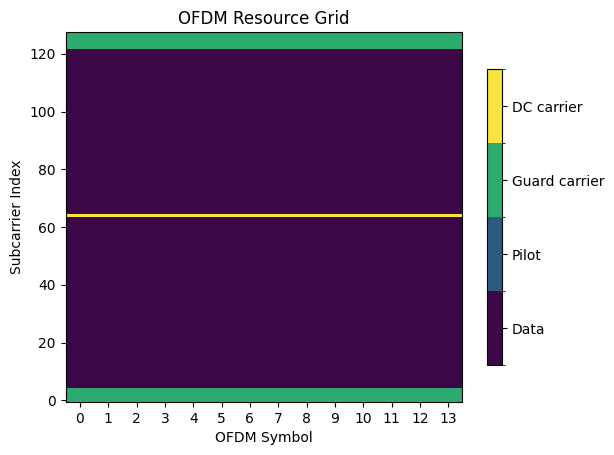

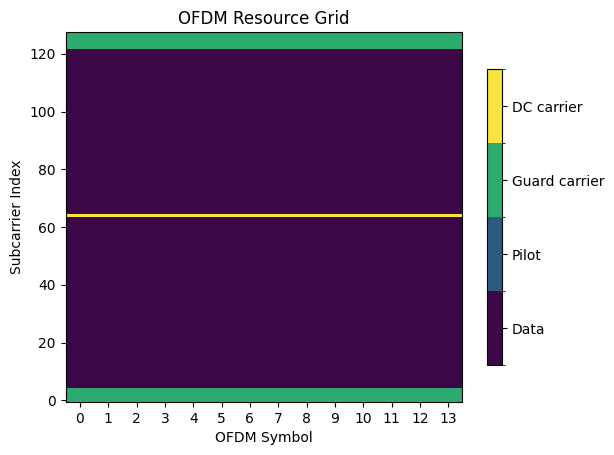

In [6]:
resource_grid = ResourceGrid(num_ofdm_symbols = num_ofdm_symbols,
                             fft_size = fft_size,
                             subcarrier_spacing = subcarrier_spacing,
                             num_tx = 1,
                             num_streams_per_tx = 1,
                             cyclic_prefix_length = cyclic_prefix_length,
                             dc_null = dc_null,
                            #  pilot_pattern = pilot_pattern,
                            #  pilot_ofdm_symbol_indices = pilot_ofdm_symbol_indices,
                             num_guard_carriers = num_guard_carriers)

resource_grid.show()

In [7]:
# Codeword length. It is calculated from the total number of databits carried by the resource grid, and the number of bits transmitted per resource element
# data symbols = 1392
n = int(resource_grid.num_data_symbols*num_bits_per_symbol)
# Number of information bits per codeword
k = int(n*coderate)
print(n)
print(k)

9744
4872


In [8]:
ut_antenna = Antenna(polarization="single",
                     polarization_type="V",
                     antenna_pattern="38.901",
                     carrier_frequency=carrier_frequency)

bs_array = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="single", # dual
                        polarization_type="V", # VH
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

## Resource Grid Util

In [9]:
class ModifiedResourceGridMapper(Layer):
    def __init__(self, resource_grid, dtype=tf.complex64, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        self._resource_grid = resource_grid
        self._rg_type = self._resource_grid.build_type_grid()
        self._pilot_ind = tf.where(self._rg_type == 1)  # Indices for pilots

    def extract_pilots(self, input_rg):
        input_rg = tf.squeeze(input_rg, axis=1)
        
        pilot_grid = tf.zeros_like(input_rg)
        pilot_values = tf.gather_nd(input_rg, self._pilot_ind)
        pilot_grid = tf.tensor_scatter_nd_update(pilot_grid, self._pilot_ind, pilot_values)
        
        pilot_grid = tf.expand_dims(pilot_grid, axis=1)
        
        return pilot_grid

    def replace(self, inputs):
        # Unpack the generated and real resource grids
        generated_y_rg, real_y_rg = inputs  # (batch, 1, 2, ofdm, subcar)

        generated_y_rg = tf.squeeze(generated_y_rg, axis=1)
        real_y_rg = tf.squeeze(real_y_rg, axis=1)

        # Extract the pilots from the real resource grid
        real_pilots = tf.gather_nd(real_y_rg, self._pilot_ind)

        # Replace the pilots in the generated resource grid with the real pilots
        updated_y_rg = tf.tensor_scatter_nd_update(generated_y_rg, self._pilot_ind, real_pilots)
        updated_y_rg = tf.expand_dims(updated_y_rg, axis=1)  # Restore dimensions

        return updated_y_rg

In [10]:
@tf.function
def add_nulled_subcarriers(h_hat_active):
        """
        Add nulled subcarriers back to channel estimate.
        h_hat_active has shape (batch, 1, 1, 14, 116)
        Returns tensor with shape (batch, 1, 1, 14, 128)
        
        This method is integrated directly into the model to ensure proper gradient flow.
        """
        # Get dynamic batch size
        batch_size = tf.shape(h_hat_active)[0]
        
        # Split the 116 active subcarriers into two groups
        h_before_dc = h_hat_active[:, :, :, :, :59]   # First 59 (positions 5-63)
        h_after_dc = h_hat_active[:, :, :, :, 59:]    # Last 57 (positions 65-121)
        
        # Create zero tensors for guard bands and DC
        dtype = h_hat_active.dtype
        zeros_guard_low = tf.zeros([batch_size, 1, 1, 14, 5], dtype=dtype)    # Positions 0-4
        zeros_dc = tf.zeros([batch_size, 1, 1, 14, 1], dtype=dtype)           # Position 64 (DC)
        zeros_guard_high = tf.zeros([batch_size, 1, 1, 14, 6], dtype=dtype)   # Positions 122-127
        
        # Concatenate in the correct order: [0-4][5-63][64][65-121][122-127]
        h_hat_full = tf.concat([
            zeros_guard_low,    # Positions 0-4 (5 zeros)
            h_before_dc,        # Positions 5-63 (59 subcarriers) 
            zeros_dc,           # Position 64 (1 zero - DC)
            h_after_dc,         # Positions 65-121 (57 subcarriers)
            zeros_guard_high    # Positions 122-127 (6 zeros)
        ], axis=-1)
        
        return h_hat_full

## Neural Receiver <a class="anchor" id="Neural-Receiver"></a>

In [11]:
class ResidualBlock(Layer):
    def __init__(self, name=None, **kwargs):
        super(ResidualBlock, self).__init__(name=name, **kwargs)
    
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

class NeuralReceiver(Model):
    def __init__(self, **kwargs):
        super(NeuralReceiver, self).__init__(**kwargs)
        self.receiver = self.build_receiver()
    
    def build_receiver(self):
        self._input_conv = Conv2D(filters=num_conv_channels,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None,
                                 name="neural_receiver_input_conv")
        self._output_conv = Conv2D(filters=num_bits_per_symbol,
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None,
                                  name="neural_receiver_output_conv")

        inputs = tf.keras.Input(shape=(14, 128, 3))
        # Input conv
        z = self._input_conv(inputs)
        # Residual blocks
        z = ResidualBlock(name="neural_receiver_residual_block_1")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_2")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_3")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_4")(z)
        # Output conv
        z = self._output_conv(z)
        
        return tf.keras.Model(inputs=inputs, outputs=z, name="Neural_receiver")

    def call(self, inputs):
        y, no = inputs

        # Feeding the noise power in log10 scale helps with the performance
        no = log10(no)

        # Stacking the real and imaginary components of the different antennas along the 'channel' dimension
        y = tf.transpose(y, [0, 2, 3, 1]) # Putting antenna dimension last
        no = insert_dims(no, 3, 1)
        no = tf.tile(no, [1, y.shape[1], y.shape[2], 1])
        # z : [batch size, num ofdm symbols, num subcarriers, 2*num rx antenna + 1]
        z = tf.concat([tf.math.real(y),
                       tf.math.imag(y),
                       no], axis=-1)

        z = self.receiver(z)

        return z

In [12]:
NR = NeuralReceiver()
NR.receiver.summary()

Model: "Neural_receiver"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 14, 128, 3)]      0         
                                                                 
 neural_receiver_input_conv  (None, 14, 128, 128)      3584      
  (Conv2D)                                                       
                                                                 
 neural_receiver_residual_b  (None, 14, 128, 128)      1212672   
 lock_1 (ResidualBlock)                                          
                                                                 
 neural_receiver_residual_b  (None, 14, 128, 128)      1212672   
 lock_2 (ResidualBlock)                                          
                                                                 
 neural_receiver_residual_b  (None, 14, 128, 128)      1212672   
 lock_3 (ResidualBlock)                            

## Conv2D GAN

In [13]:
class GANGenerator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANGenerator, self).__init__(**kwargs)
        self.generator = self.build_generator()

    def build_generator(self):
        """Builds the generator model."""
        x_real_input = tf.keras.layers.Input(shape=(14,128,2))  # (batch,14,128,2)
        noise_input = tf.keras.layers.Input(shape=(14,128,noise_dim)) 
        c_input = tf.keras.layers.Input(shape=(14,128,2))  # (batch,14,128,2) or (batch,14,128,4)
        
        x = tf.keras.layers.Concatenate()([x_real_input, noise_input, c_input])

        x = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=2, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        
        return  tf.keras.Model(inputs=[x_real_input, noise_input, c_input], outputs=x, name="GANChannel_Generator")
    
    def call(self, z, x, extra_condition):
        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0,2,3,1])
        x_real, x_imag = tf.math.real(x), tf.math.imag(x) # [batch,14,128,ant]
        x_flat = tf.concat([x_real, x_imag], axis=-1) #  [batch,14,128,2*ant]

        c = tf.squeeze(extra_condition, axis=1)
        c = tf.transpose(c, [0,2,3,1])
        c_real, c_imag = tf.math.real(c), tf.math.imag(c) # [batch,14,128,ant]
        c_flat = tf.concat([c_real, c_imag], axis=-1) #  [batch,14,128,2*ant]
        
        y = self.generator([x_flat, z, c_flat]) # [batch,14,128,2]
        
        y = tf.reshape(y, (batch_size, 14, 128, 2, 1))

        y_r = y[:, :, :, 0, :]  # (batch, 14, 128, rx_ant)
        y_i = y[:, :, :, 1, :]  # (batch, 14, 128, rx_ant) 
        y_r = tf.transpose(y_r, [0, 3, 1, 2])  # (batch, rx_ant, 14, 128)
        y_i = tf.transpose(y_i, [0, 3, 1, 2])  # (batch, rx_ant, 14, 128)
        y_complex = tf.complex(y_r, y_i)
        
        y_complex = tf.expand_dims(y_complex, axis=1)
        
        return y_complex

In [14]:
gan_generator = GANGenerator()
gan_generator.generator.summary()

Model: "GANChannel_Generator"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 14, 128, 2)]         0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 14, 128, 100)]       0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 14, 128, 2)]         0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 14, 128, 104)         0         ['input_2[0][0]',             
                                                                     'input_3[0

In [15]:
class GANDiscriminator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANDiscriminator, self).__init__(**kwargs)
        self.discriminator = self.build_discriminator()
    
    def build_discriminator(self):
        """Builds the discriminator model."""
        y_rg = tf.keras.layers.Input(shape=(14,128,6)) # 14,128,6 or 14,128,8

        y = tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same')(y_rg)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)
        y = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same')(y)
        # y = tf.keras.layers.LayerNormalization()(y)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)
        y = tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same')(y)
        # y = tf.keras.layers.LayerNormalization()(y)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)

        y = tf.keras.layers.Flatten()(y)
        # FC = tf.nn.relu(tf.keras.layers.Dense(100, activation=None)(FC))
        D_logit = tf.keras.layers.Dense(1, activation='linear')(y) # sigmoid
        # D_prob = tf.nn.sigmoid(conv4)
        
        return tf.keras.Model(inputs=y_rg, outputs=D_logit, name="GANChannel_Discriminator")
    
    def call(self, y, x, extra_condition):
        y = tf.squeeze(y, axis=1)
        y = tf.transpose(y, [0,2,3,1])
        y_real, y_imag = tf.math.real(y), tf.math.imag(y) # [batch,14,128,ant]
        y_cat = tf.concat([y_real, y_imag], axis=-1) # [batch,14,128,2*ant]

        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0,2,3,1])
        x_real, x_imag = tf.math.real(x), tf.math.imag(x) # [batch,14,128,ant]
        x_cat = tf.concat([x_real, x_imag], axis=-1) # [batch,14,128,2*ant]

        c = tf.squeeze(extra_condition, axis=1)
        c = tf.transpose(c, [0,2,3,1])
        c_real, c_imag = tf.math.real(c), tf.math.imag(c) # [batch,14,128,ant]
        c_cat = tf.concat([c_real, c_imag], axis=-1) #  [batch,14,128,2*ant]
        
        cat = tf.concat([y_cat, x_cat, c_cat], axis=-1) # [batch,14,128,c]

        y_logit = self.discriminator(cat)
        
        return y_logit

In [16]:
gan_discriminator = GANDiscriminator()
gan_discriminator.discriminator.summary()

Model: "GANChannel_Discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 14, 128, 6)]      0         
                                                                 
 conv2d_12 (Conv2D)          (None, 14, 128, 64)       3520      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 14, 128, 64)       0         
                                                                 
 conv2d_13 (Conv2D)          (None, 14, 128, 128)      73856     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 14, 128, 128)      0         
                                                                 
 conv2d_14 (Conv2D)          (None, 14, 128, 256)      295168    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 14, 12

## End-to-end System <a class="anchor" id="End-to-end-System"></a>

In [17]:
## Transmitter
binary_source = BinarySource()
# mapper = Mapper("qam", num_bits_per_symbol)
# rg_mapper = ResourceGridMapper(resource_grid)

constellation = Constellation("qam", num_bits_per_symbol, trainable=True)
mapper = Mapper(constellation=constellation)
rg_mapper = ResourceGridMapper(resource_grid)

## Channel
cdl = CDL(cdl_model, delay_spread, carrier_frequency,
          ut_antenna, bs_array, "uplink", min_speed=speed)
channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

## Receiver
neural_receiver = NeuralReceiver()
rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements

# resource grid helper
rg_util = ModifiedResourceGridMapper(resource_grid)

### Test Definition

In [18]:
batch_size = 128
ebno_db = tf.fill([batch_size], 5.0)
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
z = tf.random.normal(shape=(batch_size, 1, 14, 128))

## Transmitter
c = binary_source([batch_size, 1, 1, n])
print("c shape: ", c.shape)

# Map bits to QAM symbols
x = mapper(c)
print("x shape: ", x.shape)

# Map the QAM symbols to a resource grid
x_rg = rg_mapper(x)
print("x_rg shape: ", x_rg.shape)

######################################
## Channel
# A batch of new channel realizations is sampled and applied at every inference
no_ = expand_to_rank(no, tf.rank(x_rg))
y,_ = channel([x_rg, no_])
print("y shape: ", y.shape)
y_p = rg_util.extract_pilots(y)
print("y_p shape: ", y_p.shape)

######################################
## Receiver
# The neural receover computes LLRs from the frequency domain received symbols and N0
y = tf.squeeze(y, axis=1)
llr = neural_receiver([y, no])
print("llr shape: ", llr.shape)
# Reshape the input to fit what the resource grid demapper is expected
llr = insert_dims(llr, 2, 1)
# Extract data-carrying resource elements. The other LLRs are discarded
llr = rg_demapper(llr) # 1392 from 1792 (14*128)
print("LLRs before reshape: ", llr.shape)
llr = tf.reshape(llr, [batch_size, 1, 1, n])
print("Post RG-demapper LLRs: ", llr.shape)

2025-08-29 15:43:02.984251: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


c shape:  (128, 1, 1, 9744)
x shape:  (128, 1, 1, 1624)
x_rg shape:  (128, 1, 1, 14, 128)
y shape:  (128, 1, 1, 14, 128)
y_p shape:  (128, 1, 1, 14, 128)


2025-08-29 15:43:05.109469: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2025-08-29 15:43:05.377934: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


llr shape:  (128, 14, 128, 6)
LLRs before reshape:  (128, 1, 1, 1624, 6)
Post RG-demapper LLRs:  (128, 1, 1, 9744)


In [19]:
bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
bce = tf.reduce_mean(bce)
rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
print(f"Rate: {rate:.2E} bit")

Rate: -7.89E-01 bit


## End-to-end System as a Keras Model <a class="anchor" id="End-to-end-System-as-a-Keras-Model"></a>

In [36]:
class E2ESystem(Model):
    def __init__(self, training=False):
        super().__init__()
        self._training = training
        self.x_rg = None
        self.y_gen = None
        self.y_real = None
        self.h_freq = None
        self.prior_constellation = None
        self.post_constellation = None
        # self.ls_estimator = LSChannelEstimator(resource_grid, interpolation_type="nn")

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training:
            self._encoder = LDPC5GEncoder(k, n)
            
        # Trainable constellation
        constellation = Constellation("qam", num_bits_per_symbol, trainable=True)
        self.constellation = constellation
        self._mapper = Mapper(constellation=constellation)
        self._rg_mapper = ResourceGridMapper(resource_grid)         

        ######################################
        ## Channel
        # A 3GPP CDL channel model is used
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed)
        self._real_channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

        self._gan_channel = GANGenerator()

        ######################################
        ## Receiver
        self._neural_receiver = NeuralReceiver()
        self._rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements
            
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training:
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)
    
    @tf.function
    def call(self, batch_size, ebno_db, use_gan_channel=False):
        
        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created as it is what is expected by some layers
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)

        ######################################
        ## Transmitter
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        
        # Outer coding is only performed if not training
        if self._training:
            c = self._binary_source([batch_size, 1, 1, n]) # u=4176*2
        else:
            b = self._binary_source([batch_size, 1, 1, k]) # k=4176
            c = self._encoder(b) # u=n=4176*2
        
        # c = self._binary_source([batch_size, 1, 1, n]) # for uncoded simulation
        
        # Modulation
        self.prior_constellation = c
        x = self._mapper(c)
        self.post_constellation = x
        
        x_rg = self._rg_mapper(x)

        self.x_rg = x_rg

        ######################################
        ## Channel
        # A batch of new channel realizations is sampled and applied at every inference
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y,h = self._real_channel([x_rg, no_])

        self.y_real = y

        ### ----------------- GAN channel
        if use_gan_channel: 
            z = tf.random.normal([batch_size, 14, 128, noise_dim])
            
            # h_freq = h[:,:,:,0,0,:,:]
        
            condition = self.y_real # y_real, h_freq
            
            y = self._gan_channel(z, x_rg, condition)
            
            self.h_freq = h
            self.y_gen = y
            
        ######################################
        ## Receiver    
        # The neural receover computes LLRs from the frequency domain received symbols and N0
        y = tf.squeeze(y, axis=1)
        llr = self._neural_receiver([y, no])
        llr = insert_dims(llr, 2, 1) # Reshape the input to fit what the resource grid demapper is expected
        llr = self._rg_demapper(llr) # Extract data-carrying resource elements. The other LLrs are discarded
        llr = tf.reshape(llr, [batch_size, 1, 1, n]) # Reshape the LLRs to fit what the outer decoder is expected

        # Outer coding is not needed if the information rate is returned
        if self._training:
            # Compute and return BMD rate (in bit), which is known to be an achievable
            # information rate for BICM systems. Training aims at maximizing the BMD rate
            bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            if use_gan_channel:
                return rate, self.x_rg, self.y_gen, self.y_real, self.h_freq, no_
            else:
                return rate
        else:
            # Outer decoding
            b_hat = self._decoder(llr)
            return b,b_hat # k=4176
            # probabilities = tf.math.sigmoid(llr)
            # b_hat = tf.cast(probabilities > 0.5, dtype=tf.float32) # 0.5-1 is False=bit 0; 0-0.5 is True=bit 1 
            # return c,b_hat # Ground truth and reconstructed information bits returned for BER/BLER computation

## PSD

In [21]:
def compute_psd_line(y):
    y = tf.squeeze(y, axis=[1,2])
    fft_result = tf.signal.fft(y)  # Shape: [batch, 14, 128]
    power_db = 20 * tf.math.log(tf.abs(fft_result) + 1e-10) / tf.math.log(10.0)  # Convert to dB
    power_db_shifted = tf.signal.fftshift(power_db, axes=[-1])  # Shape: [batch, 14, 128]
    return tf.reduce_mean(power_db_shifted, axis=1)  # Shape: [batch, 128]

def plot_psd_line(psd_real, psd_fake):
    # Convert to NumPy and average over batch
    psd_real_np = psd_real.numpy().mean(axis=0)  # Shape: [128]
    psd_fake_np = psd_fake.numpy().mean(axis=0)  # Shape: [128]
    
    # Frequency axis (normalized subcarriers)
    freq_axis = np.linspace(-0.5, 0.5, psd_real_np.shape[-1])  # Normalized frequencies
    # Plot
    plt.figure(figsize=(8, 2))
    plt.plot(freq_axis, psd_real_np, label="Real PSD", linewidth=2)
    plt.plot(freq_axis, psd_fake_np, label="Generated PSD", linewidth=2)
    plt.xlabel("Normalized Frequency")
    plt.ylabel("PSD (dB)")
    plt.title("Power Spectral Density of OFDM Signal")
    plt.legend()
    plt.grid()
    plt.show()

def compute_psd(y):
    y = tf.squeeze(y, axis=[1,2])
    # fft_result = tf.signal.fft2d(y)
    # power = tf.abs(fft_result)**2
    fft_result = tf.signal.fft(y) 
    power_db = 20 * tf.math.log(tf.abs(fft_result) + 1e-10) / tf.math.log(10.0)  # Convert to dB
    power = tf.signal.fftshift(power_db, axes=[-1])  # Shape: [batch, 14, 128]
    # Average over the batch dimension
    psd = tf.reduce_mean(power, axis=0)  # Shape: [14, 128]
    
    return psd

def plot_psd(psd_real, psd_generated):
    vmin = min(np.min(psd_real.numpy()), np.min(psd_generated.numpy()))
    vmax = max(np.max(psd_real.numpy()), np.max(psd_generated.numpy()))

    plt.figure(figsize=(12, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(psd_real.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Real PSD')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(psd_generated.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Generated PSD')
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()

In [22]:
def plot_phase_amp_distribution(real_y, generated_y):
    phase_real = tf.math.angle(real_y).numpy().flatten()
    phase_fake = tf.math.angle(generated_y).numpy().flatten()

    plt.figure(figsize=(7, 3))
    plt.subplot(1, 2, 1)
    bins = np.linspace(-np.pi, np.pi, 50)
    plt.hist(phase_real, bins=bins, alpha=0.5, label="Real", density=True)
    plt.hist(phase_fake, bins=bins, alpha=0.5, label="Generated", density=True)
    plt.xlabel("Phase (radians)")
    plt.ylabel("Density")
    plt.title("Phase Distribution")
    plt.legend()
    plt.grid()
    
    real_amplitude = np.abs(real_y).flatten()
    gen_amplitude = np.abs(generated_y).flatten()
    
    plt.subplot(1, 2, 2)  
    all_data = np.concatenate((real_amplitude, gen_amplitude))
    bins = np.linspace(np.min(all_data), np.max(all_data), 50)  # Define bins properly
    plt.hist(real_amplitude, bins=bins, density=True, alpha=0.5, color='blue', label='Real')
    plt.hist(gen_amplitude, bins=bins, density=True, alpha=0.5, color='red', label='Generated')
    plt.xlabel("Amplitude")
    plt.ylabel("Density")
    plt.title("Amplitude Distribution")
    plt.legend()
    plt.grid()
    
    plt.tight_layout()
    plt.show()

## Training Parameters

In [23]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     0.5) # Step

# Dictionnary storing the evaluation results
BLER = {}
BER = {}

In [24]:
def gradient_penalty(disc, y_real, y_fake, x_real, condition):
    lamb = 10
    batchlen = tf.shape(y_real)[0]  # batch size of y_real or y_fake
    
    epsilon = tf.random.uniform([batchlen, 1,1,1,1], minval=0, maxval=1, dtype=tf.float32) # interpolation factor (0-1)
    # epsilon = epsilon[:, None, None, None, None]
    
    # Interpolating between real and fake post-fft y
    y_real = tf.cast(y_real, tf.float32)
    y_fake = tf.cast(y_fake, tf.float32)
    interpolated = epsilon * y_real + (1 - epsilon) * y_fake
    
    # Gradient calculation
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        D_logit_pred = disc(interpolated, x_real, condition)

    grads = gp_tape.gradient(D_logit_pred, interpolated)

    # num_elements = tf.reduce_prod(tf.shape(grads)[1:])
    grad_norms = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3,4])) # / tf.cast(num_elements, tf.float32) )
    # print(tf.reduce_mean(grads), tf.reduce_mean(grad_norms))
    
    gp = lamb * tf.reduce_mean(tf.square(grad_norms - 1))
    # gp = lamb * tf.reduce_mean(tf.clip_by_value(grad_norms - 1., 0., np.infty)**2)
    
    return gp, tf.reduce_mean(grad_norms)

In [37]:
# -------- only rerun this cell if need to reset training
model = E2ESystem(training=True)
eval_model = E2ESystem(training=False)

WG = GANGenerator()
WD = GANDiscriminator()

list_D = []
list_G = []

# Parameters
lr = 0.0001
epoch = 4000
snr_db = 10.0  # in dB

optimizer_G = tf.keras.optimizers.Adam(lr, beta_1=0.5, beta_2=0.9)
optimizer_D = tf.keras.optimizers.Adam(lr, beta_1=0.5, beta_2=0.9)

# # offset
# model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=True)
# with open('gan_weights/gan_weights_G_1000.pkl', 'rb') as f:
#     g_weights = pickle.load(f)
# WG.set_weights(g_weights)
# with open('gan_weights/gan_weights_D_1000.pkl', 'rb') as f:
#     d_weights = pickle.load(f)
# WD.set_weights(d_weights)

In [26]:
@tf.function
def WGAN_train_step(y_real, x_rg, condition):
    z = tf.random.normal([batch_size, 14, 128, noise_dim])
    y_fake = WG(z, x_rg, condition)

    # Train Discriminator
    for j in range(1): # DISCRIMINATOR_TRAININGS_PER_GENERATOR_TRAINING adjust accordingly
        with tf.GradientTape() as tape_D:
            d_real = WD(y_real, x_rg, condition)
            d_fake = WD(y_fake, x_rg, condition)

            gp, grad_norm = gradient_penalty(WD, y_real, y_fake, x_rg, condition)
            loss_D = tf.reduce_mean(d_fake) - tf.reduce_mean(d_real) + gp
            
        grads_D = tape_D.gradient(loss_D, WD.trainable_variables)
        optimizer_D.apply_gradients(zip(grads_D, WD.trainable_variables))

    # Train Generator
    for k in range(1): # adjust accordingly
        with tf.GradientTape() as tape_G:
            y_fake = WG(z, x_rg, condition)
            d_fake = WD(y_fake, x_rg, condition)
            
            loss_G = -tf.reduce_mean(d_fake)
            
        grads_G = tape_G.gradient(loss_G, WG.trainable_variables)
        optimizer_G.apply_gradients(zip(grads_G, WG.trainable_variables))
    
    return d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake

In [27]:
optimizer = tf.keras.optimizers.legacy.Adam()

@tf.function
def E2E_train__tx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, (Constellation, Mapper)):
            layer.trainable = True  
        else:
            layer.trainable = False  
    tx_weights = model.trainable_weights
    # for w in tx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate, _, y_gen, y_real, h_freq, _ = model(training_batch_size, ebno_db, use_gan_channel=True)
        loss = -rate 
    
    grads_tx = tape.gradient(loss, tx_weights)
    optimizer.apply_gradients(zip(grads_tx, tx_weights))
    
    return loss, y_gen, y_real

@tf.function
def E2E_train__rx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, NeuralReceiver):
            layer.trainable = True 
        else:
            layer.trainable = False
    rx_weights = model.trainable_weights
    # for w in rx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(training_batch_size, ebno_db, use_gan_channel=False)
        loss = -rate 
    
    grads_rx = tape.gradient(loss, rx_weights)
    optimizer.apply_gradients(zip(grads_rx, rx_weights))

    return loss

## Training the WGAN

  0%|          | 0/4001 [00:00<?, ?it/s]

2025-08-22 08:18:33.239013: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f28ea6f0eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-22 08:18:33.239070: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A2000 12GB, Compute Capability 8.6
2025-08-22 08:18:33.245817: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1755814713.351897    6197 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch [0/4000] w_d:-0.0045 gp: 8.8311, grad_norm: 0.0603 Loss_D: 8.8267 Loss_G: -0.3589, mse(PSD): 129.3511
(0.01295989-0.25290826j) (-0.0011222714-0.00085717236j)


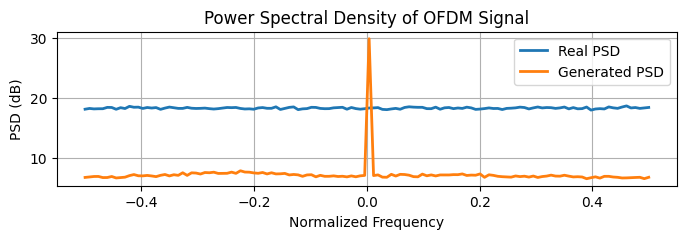

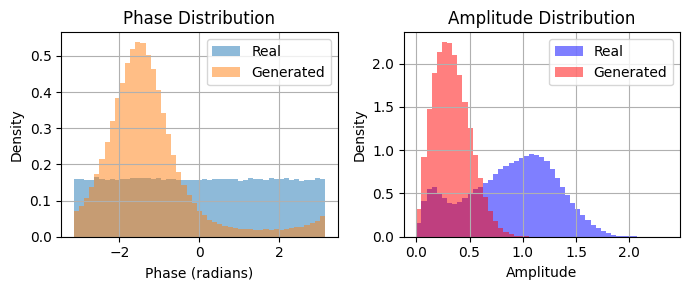

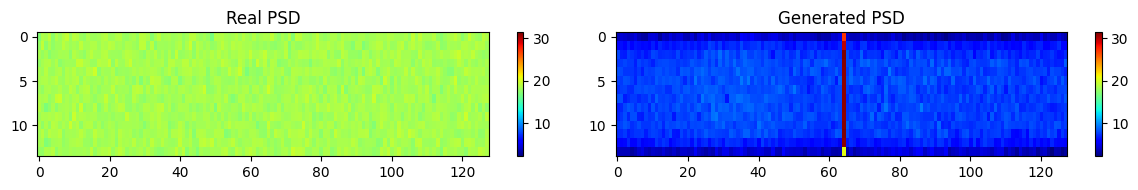

Epoch [100/4000] w_d:-49.8405 gp: 5.7598, grad_norm: 1.7395 Loss_D: -44.0807 Loss_G: -117.3592, mse(PSD): 435.8678
Epoch [200/4000] w_d:-140.1089 gp: 48.4275, grad_norm: 3.1800 Loss_D: -91.6814 Loss_G: -209.4903, mse(PSD): 67.4906
Epoch [300/4000] w_d:-54.2234 gp: 14.3579, grad_norm: 2.1767 Loss_D: -39.8655 Loss_G: 139.9512, mse(PSD): 8.4604
Epoch [400/4000] w_d:-36.5248 gp: 8.3596, grad_norm: 1.8977 Loss_D: -28.1652 Loss_G: 222.5741, mse(PSD): 4.5988
Epoch [500/4000] w_d:-34.8646 gp: 6.6412, grad_norm: 1.7928 Loss_D: -28.2235 Loss_G: 349.7652, mse(PSD): 2.0163
(0.036352396+0.021510331j) (0.000409626-5.9654336e-05j)


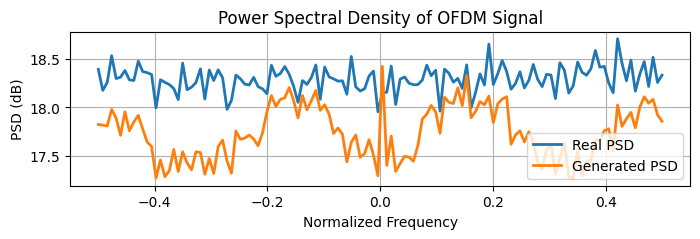

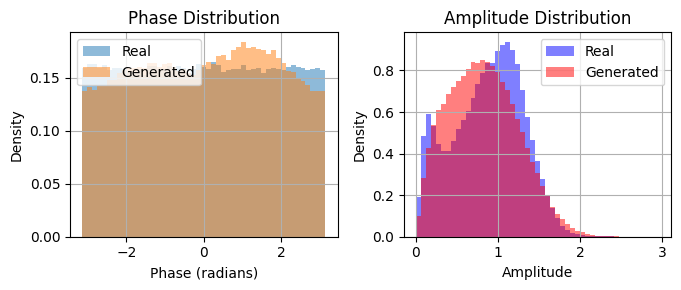

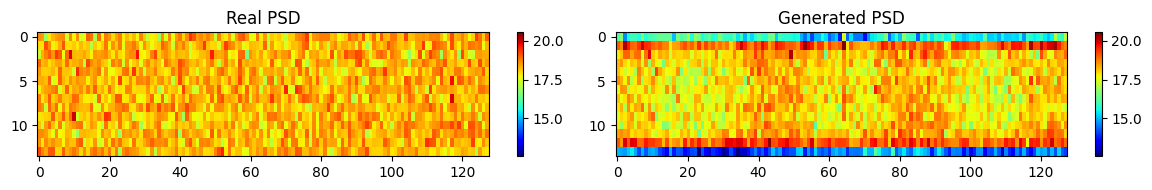

Epoch [600/4000] w_d:-52.9151 gp: 8.7252, grad_norm: 1.9161 Loss_D: -44.1899 Loss_G: 430.7522, mse(PSD): 0.5785
Epoch [700/4000] w_d:-62.3479 gp: 11.8810, grad_norm: 2.0811 Loss_D: -50.4669 Loss_G: 429.7803, mse(PSD): 0.2245
Epoch [800/4000] w_d:-72.1194 gp: 18.1901, grad_norm: 2.3447 Loss_D: -53.9293 Loss_G: 351.6487, mse(PSD): 0.1794
Epoch [900/4000] w_d:-98.0967 gp: 24.3014, grad_norm: 2.5565 Loss_D: -73.7953 Loss_G: 166.3152, mse(PSD): 0.1531
Epoch [1000/4000] w_d:-140.6962 gp: 29.6339, grad_norm: 2.7177 Loss_D: -111.0623 Loss_G: -118.1439, mse(PSD): 0.1147
(-0.027092423+0.005512978j) (0.00093452394-0.0011173595j)


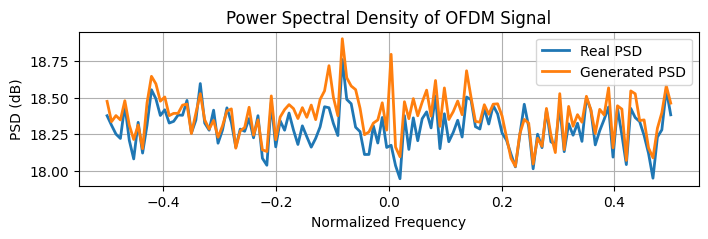

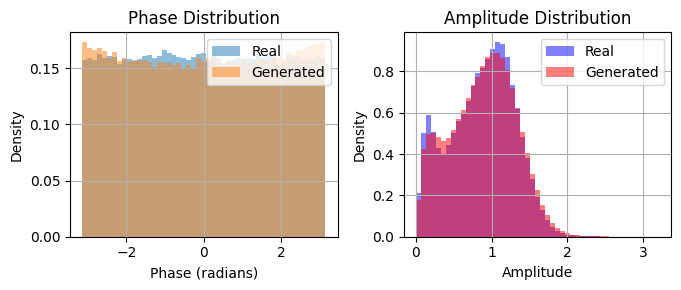

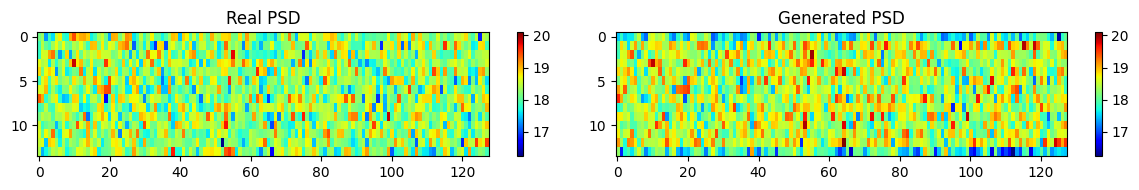

Epoch [1100/4000] w_d:-217.6510 gp: 35.9159, grad_norm: 2.8901 Loss_D: -181.7351 Loss_G: -628.6667, mse(PSD): 0.0635
Epoch [1200/4000] w_d:-393.6252 gp: 55.2320, grad_norm: 3.3292 Loss_D: -338.3932 Loss_G: -1460.8093, mse(PSD): 0.0416
Epoch [1300/4000] w_d:-796.1946 gp: 156.3410, grad_norm: 4.1144 Loss_D: -639.8536 Loss_G: -2828.0425, mse(PSD): 0.0393
Epoch [1400/4000] w_d:-1191.6733 gp: 265.2582, grad_norm: 4.7352 Loss_D: -926.4152 Loss_G: -4795.5454, mse(PSD): 0.0339
Epoch [1500/4000] w_d:-1250.7646 gp: 383.9578, grad_norm: 5.7986 Loss_D: -866.8068 Loss_G: -7126.9531, mse(PSD): 0.0501
(0.0071100607+0.006280592j) (0.0014015727+0.0025077744j)


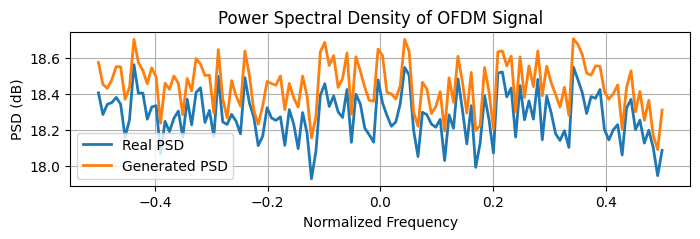

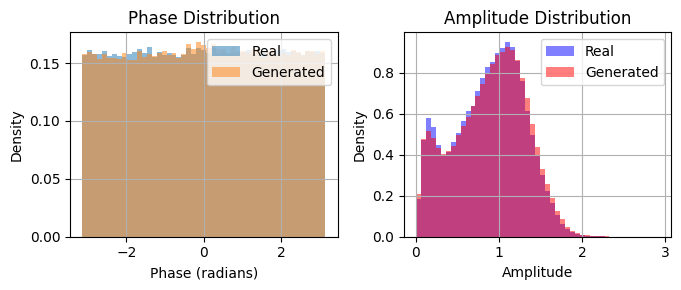

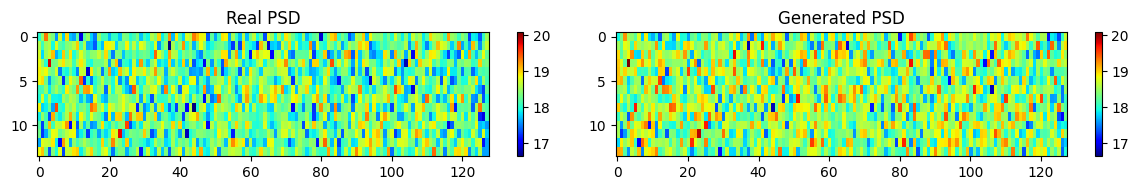

Epoch [1600/4000] w_d:-1558.5732 gp: 638.4659, grad_norm: 6.2543 Loss_D: -920.1074 Loss_G: -7703.7510, mse(PSD): 0.0285
Epoch [1700/4000] w_d:-2190.0078 gp: 465.8109, grad_norm: 5.8222 Loss_D: -1724.1970 Loss_G: -10052.9453, mse(PSD): 0.0190
Epoch [1800/4000] w_d:-4609.5469 gp: 223.9809, grad_norm: 5.2990 Loss_D: -4385.5659 Loss_G: -12182.7441, mse(PSD): 0.0421
Epoch [1900/4000] w_d:-7136.3721 gp: 568.0088, grad_norm: 6.2045 Loss_D: -6568.3633 Loss_G: -14394.8545, mse(PSD): 0.0359
Epoch [2000/4000] w_d:-8999.8652 gp: 331.9358, grad_norm: 6.6699 Loss_D: -8667.9297 Loss_G: -19058.1191, mse(PSD): 0.0118
(-0.011914127-0.010933413j) (0.00028941748-0.00020466812j)


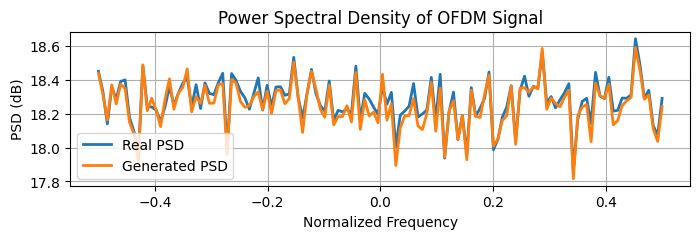

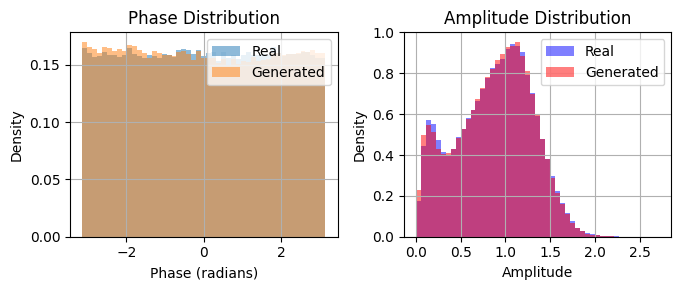

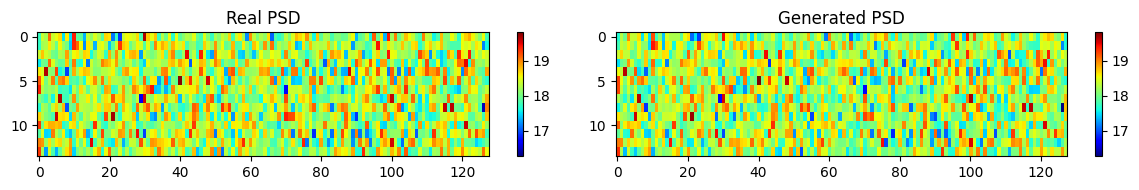

Epoch [2100/4000] w_d:-14217.6094 gp: 716.9012, grad_norm: 8.4512 Loss_D: -13500.7080 Loss_G: -21609.1641, mse(PSD): 0.0274
Epoch [2200/4000] w_d:-19007.7930 gp: 683.0511, grad_norm: 9.0299 Loss_D: -18324.7422 Loss_G: -28756.5078, mse(PSD): 0.0137
Epoch [2300/4000] w_d:-25735.1992 gp: 672.3633, grad_norm: 8.6650 Loss_D: -25062.8359 Loss_G: -36506.2812, mse(PSD): 0.0101
Epoch [2400/4000] w_d:-34600.8750 gp: 476.7395, grad_norm: 7.7365 Loss_D: -34124.1367 Loss_G: -47869.0273, mse(PSD): 0.0077
Epoch [2500/4000] w_d:-51385.0547 gp: 533.5963, grad_norm: 7.5040 Loss_D: -50851.4570 Loss_G: -55613.8984, mse(PSD): 0.0123
(0.031512666-0.009722696j) (0.0015802364+0.0007685009j)


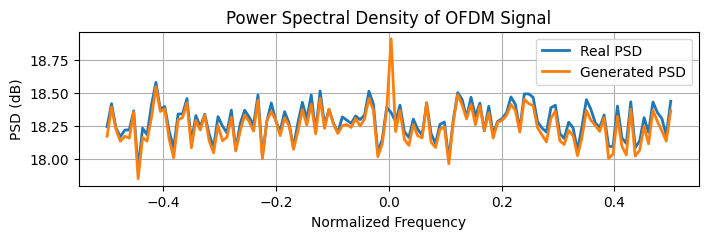

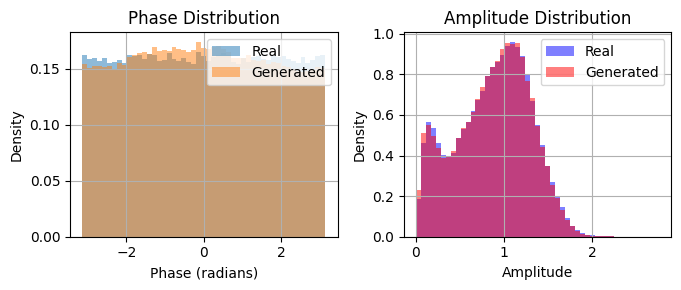

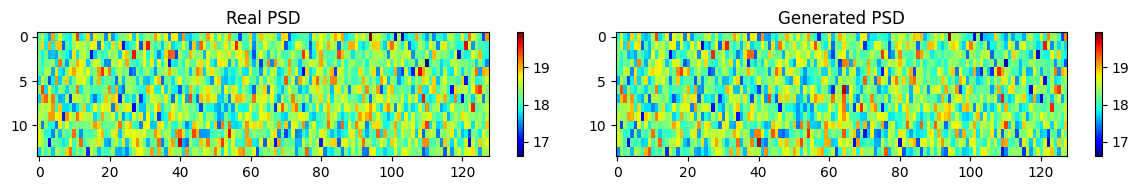

Epoch [2600/4000] w_d:-53893.4219 gp: 352.7317, grad_norm: 6.9235 Loss_D: -53540.6914 Loss_G: -85304.3281, mse(PSD): 0.0083
Epoch [2700/4000] w_d:-70167.4219 gp: 1184.7322, grad_norm: 9.0132 Loss_D: -68982.6875 Loss_G: -105126.8594, mse(PSD): 0.0086
Epoch [2800/4000] w_d:-109590.1562 gp: 623.3018, grad_norm: 8.6251 Loss_D: -108966.8516 Loss_G: -110117.6328, mse(PSD): 0.0232
Epoch [2900/4000] w_d:-113371.6875 gp: 1108.7318, grad_norm: 10.0263 Loss_D: -112262.9531 Loss_G: -156586.6562, mse(PSD): 0.0063
Epoch [3000/4000] w_d:-125636.1719 gp: 830.3704, grad_norm: 9.6112 Loss_D: -124805.8047 Loss_G: -196290.1875, mse(PSD): 0.0060
(0.0030627938-0.006892629j) (-0.0019458866+0.00049967103j)


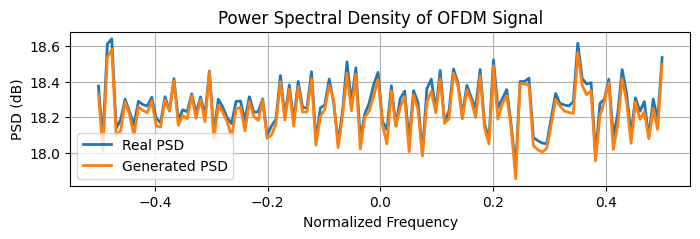

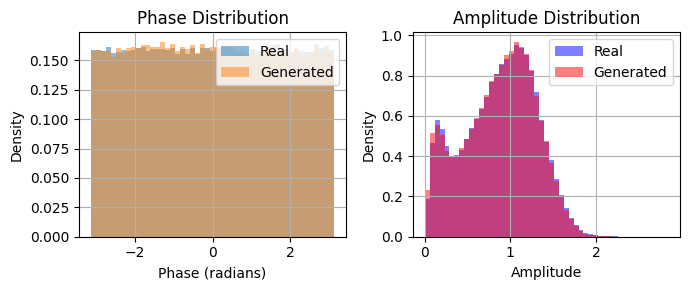

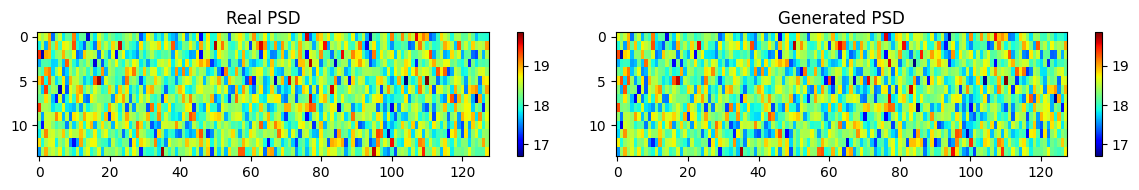

Epoch [3100/4000] w_d:-155985.2500 gp: 1215.5193, grad_norm: 10.9385 Loss_D: -154769.7344 Loss_G: -219804.8594, mse(PSD): 0.0078
Epoch [3200/4000] w_d:-166558.2500 gp: 1427.7350, grad_norm: 12.5288 Loss_D: -165130.5156 Loss_G: -270248.8750, mse(PSD): 0.0051
Epoch [3300/4000] w_d:-210694.6875 gp: 1129.7424, grad_norm: 11.5541 Loss_D: -209564.9375 Loss_G: -285986.5938, mse(PSD): 0.0056
Epoch [3400/4000] w_d:-222286.5625 gp: 2038.6643, grad_norm: 13.7783 Loss_D: -220247.8906 Loss_G: -331784.2188, mse(PSD): 0.0055
Epoch [3500/4000] w_d:-232270.0000 gp: 2934.3469, grad_norm: 13.9916 Loss_D: -229335.6562 Loss_G: -389315.5625, mse(PSD): 0.0046
(-0.0032594148-0.00941816j) (0.001454078-0.0006199939j)


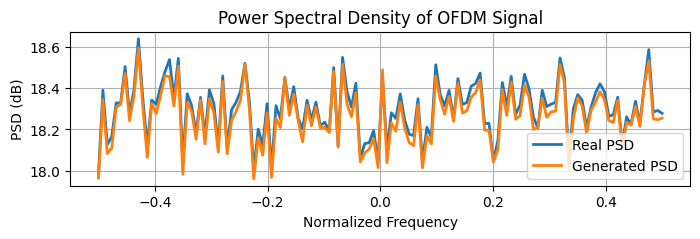

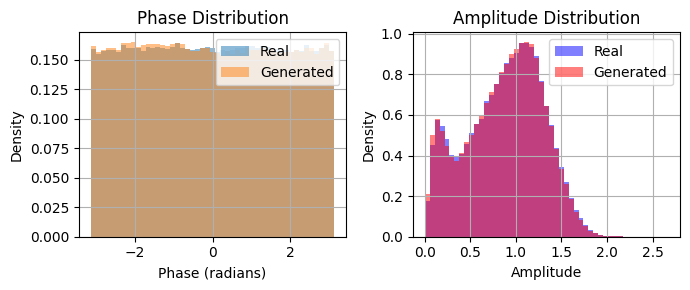

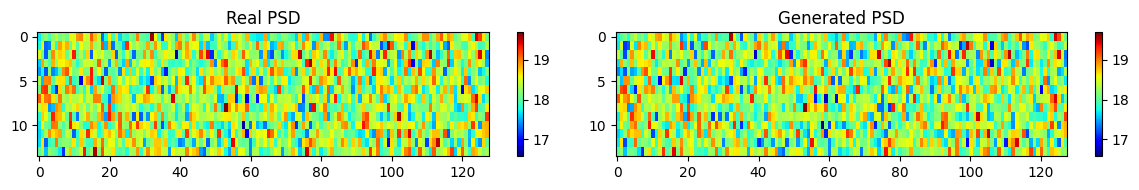

Epoch [3600/4000] w_d:-253896.7812 gp: 2137.0293, grad_norm: 14.6695 Loss_D: -251759.7500 Loss_G: -432708.4062, mse(PSD): 0.0096
Epoch [3700/4000] w_d:-275930.7812 gp: 2717.5020, grad_norm: 17.4676 Loss_D: -273213.2812 Loss_G: -485464.1875, mse(PSD): 0.0060
Epoch [3800/4000] w_d:-290387.0000 gp: 5020.2812, grad_norm: 18.6762 Loss_D: -285366.7188 Loss_G: -536274.3125, mse(PSD): 0.0051
Epoch [3900/4000] w_d:-330454.4375 gp: 14035.1582, grad_norm: 19.8730 Loss_D: -316419.2812 Loss_G: -567033.0000, mse(PSD): 0.0102
Epoch [4000/4000] w_d:-347053.0000 gp: 2649.3789, grad_norm: 16.8486 Loss_D: -344403.6250 Loss_G: -630780.0625, mse(PSD): 0.0041
(-0.015215511+0.00746118j) (0.00017577593+0.0008573785j)


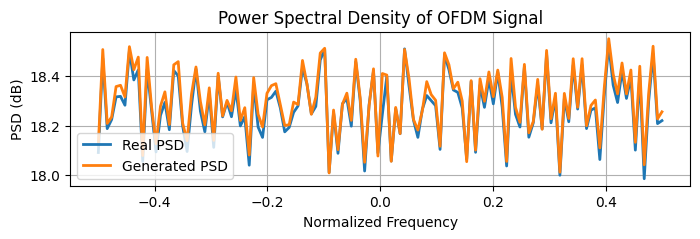

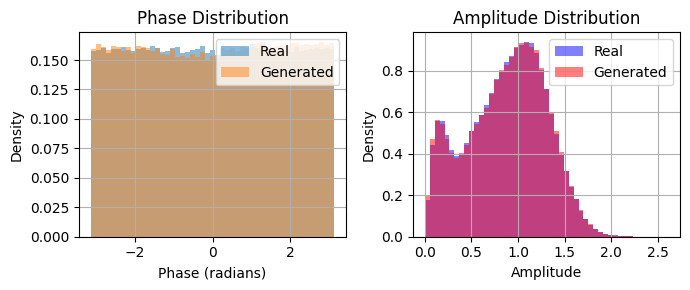

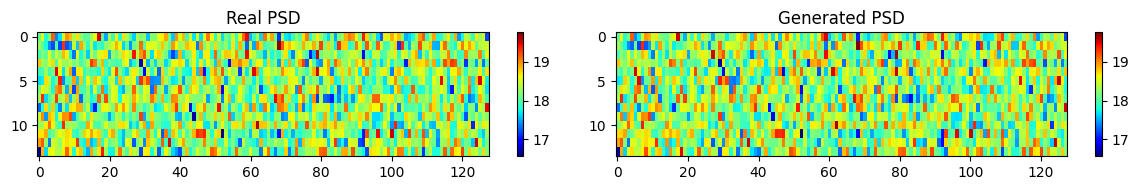

In [28]:
for i in tqdm(range(0, epoch+1)):    
    # Sampling a batch of SNRs
    # ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    ebno_db = tf.constant(10.0, tf.float32)
    
    _, x_rg, _, y_real, h_freq, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)

    # h_real = h_freq[:,:,:,0,0,:,:] # (128, 1, 1, 14, 128)

    # condition
    condition = y_real # y_real, h_real
    
    d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, y_real)
    
    gan_weights_G = WG.get_weights()
    gan_weights_D = WD.get_weights()

    # ----------------------------------------------------------------------- 
    list_D.append(loss_D)
    list_G.append(loss_G)
        
    if i % 100 == 0: 
        psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
        psd_generated = compute_psd(y_fake)
        mse_psd = tf.reduce_mean((psd_real - psd_generated)**2)

        print(f"Epoch [{i}/{epoch}] w_d:{loss_D.numpy()-gp.numpy():.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, mse(PSD): {mse_psd.numpy():.4f}") 
    
    if i % 500 == 0:    
        print(np.mean(y_fake), np.mean(y_real))
        
        psd_real_line = compute_psd_line(y_real)
        psd_generated_line = compute_psd_line(y_fake)
        plot_psd_line(psd_real_line, psd_generated_line)
        
        plot_phase_amp_distribution(y_real, y_fake)

        plot_psd(psd_real, psd_generated)

    if i % 1000 == 0: 
        # save GAN weights
        with open(f'gan_weights/gan_weights_G_receivedY_{i}.pkl', 'wb') as f2:
            pickle.dump(gan_weights_G, f2)
        with open(f'gan_weights/gan_weights_D_receivedY_{i}.pkl', 'wb') as f3:
                pickle.dump(gan_weights_D, f3)

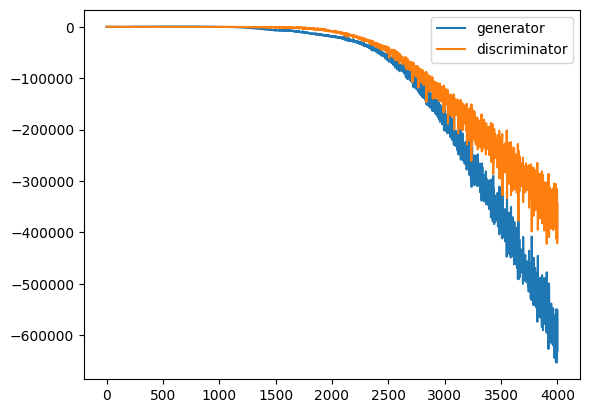

In [29]:
G_L = np.asarray(list_G)
D_L = np.asarray(list_D)

plt.figure()
plt.plot(G_L, label='generator')
plt.plot(D_L, label='discriminator')
plt.legend()
plt.savefig('gan_loss_plot_receivedY.png', dpi=300)
plt.show()

np.savez('gan_losses_none.npz', generator=G_L, discriminator=D_L)

## Training Nerual Transmitter and Receiver <a class="anchor" id="Training-the-Neural-Receiver"></a>

In [ ]:
# model(1, tf.constant(10.0, tf.float32), use_gan_channel=True)
# model.summary()
eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
# eval_model.summary()
e_weights = eval_model.trainable_weights
for w in e_weights:
    print(f"Layer: {w.name}, Shape: {w.shape}")

In [ ]:
# for layer in model.layers:
#     if isinstance(layer, NeuralReceiver):
#         layer.trainable = True  # Ensure the receiver is trainable
#     else:
#         layer.trainable = False  # Freeze all other layers
for layer in model.layers:
        layer.trainable = True
weights = model.trainable_weights
for w in weights:
    print(f"Layer: {w.name}, Shape: {w.shape}")

In [ ]:
offset = 0
model = E2ESystem(training=True)
eval_model = E2ESystem(training=False)
model(training_batch_size, ebno_db, use_gan_channel=False)
# with open('weights_trained/model_weights_50000.pkl', 'rb') as f:
#     weights = pickle.load(f)
# model.set_weights(weights)  
with open('ofdm_wgan_weights_G_conv2d_3000.pkl', 'rb') as f:
    gan_weights_G = pickle.load(f)
model._gan_channel.set_weights(gan_weights_G)

# -----------------------------------------------------------------
for i in tqdm(range(offset, num_training_iterations+1)): 
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    loss_tx, y_gen, y_real = E2E_train__tx_step(ebno_db)

    if i % 1000 == 0:
        with open(f'y_output/tx_generated_y_{i}.txt', 'w') as f1:
            np.savetxt(f1, y_gen.numpy().reshape(-1), fmt='%.6f')
        with open(f'y_output/tx_real_y_{i}.txt', 'w') as f2:
            np.savetxt(f2, y_real.numpy().reshape(-1), fmt='%.6f')
    
    loss_rx = E2E_train__rx_step(ebno_db)
     
    for layer in model.layers:
        layer.trainable = True
    weights = model.get_weights()
        
    if i % 1000 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss_tx: {loss_tx.numpy():.4f}, Loss_rx: {loss_rx.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
        eval_model.set_weights(weights)
        # validation at 3.5dB
        ber, bler = sim_ber(eval_model, [3.5], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 1000 == 0:
        with open(f'weights_trained/model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open(model_weights_path_trained, 'wb') as f:
    pickle.dump(weights, f)

## Joint training

In [31]:
# pre-trained until converge (or 4000 iterations)
model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=True)
with open('gan_weights/gan_weights_G_receivedY_4000.pkl', 'rb') as f:
    g_weights = pickle.load(f)
WG.set_weights(g_weights)
with open('gan_weights/gan_weights_D_receivedY_4000.pkl', 'rb') as f:
    d_weights = pickle.load(f)
WD.set_weights(d_weights)

  0%|          | 0/50001 [00:00<?, ?it/s]

Epoch [0/5000] w_d:-365553.5625 gp: 2329.7642, grad_norm: 16.2362 Loss_D: -363223.8125 Loss_G: -611927.8750, mse(PSD): 0.0038
(0.022692194-0.0038505138j) (-0.0032656135+0.00095171836j)


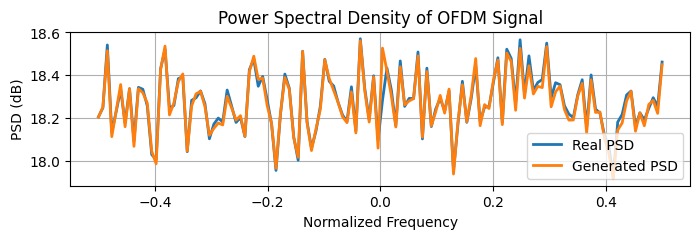

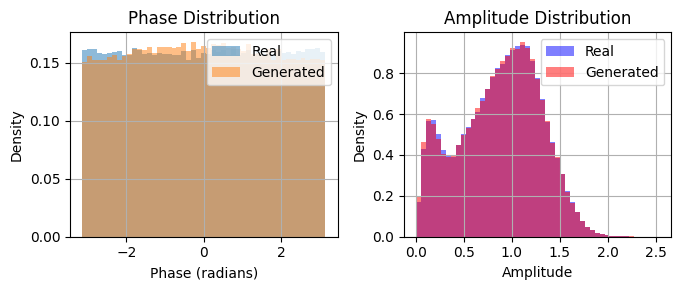

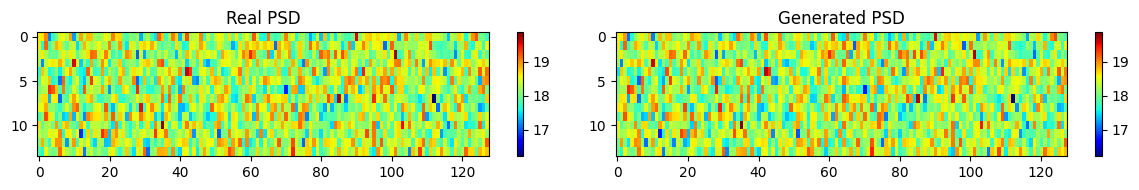

Iteration 0/50000, Eb/No: 13.8100, Loss_tx: 1.0676, Loss_rx: 1.0709
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.0097e-01 | 1.0000e+00 |      312414 |      623616 |          128 |         128 |         0.4 |reached target block errors
Epoch [100/5000] w_d:-390310.2500 gp: 5069.9897, grad_norm: 19.9196 Loss_D: -385240.2500 Loss_G: -729545.3750, mse(PSD): 0.0049
Iteration 1000/50000, Eb/No: 11.3224, Loss_tx: -0.6536, Loss_rx: -0.6441
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 8.2340e-03 | 6.0268e-02 |       35944 |     4365312 |           54 |     

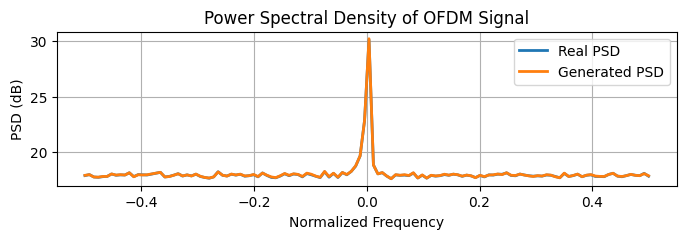

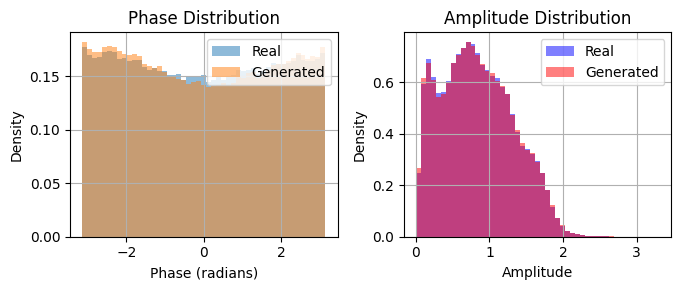

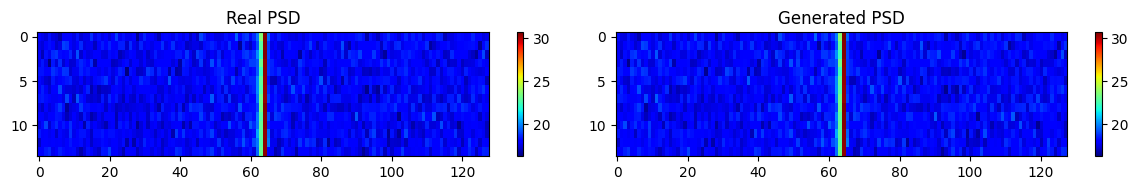

Epoch [300/5000] w_d:-456073.8750 gp: 5240.7100, grad_norm: 23.4850 Loss_D: -450833.1562 Loss_G: -812881.9375, mse(PSD): 0.0087
Iteration 3000/50000, Eb/No: 10.1823, Loss_tx: -0.6499, Loss_rx: -0.6708
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.2030e-03 | 2.7902e-02 |       36695 |     8730624 |           50 |        1792 |         5.8 |reached target block errors
Epoch [400/5000] w_d:-504294.6875 gp: 3763.2573, grad_norm: 19.4680 Loss_D: -500531.4375 Loss_G: -842611.1250, mse(PSD): 0.0038
Iteration 4000/50000, Eb/No: 16.7115, Loss_tx: -0.7770, Loss_rx: -0.7995
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
----------------------------------------------------------------------------------------

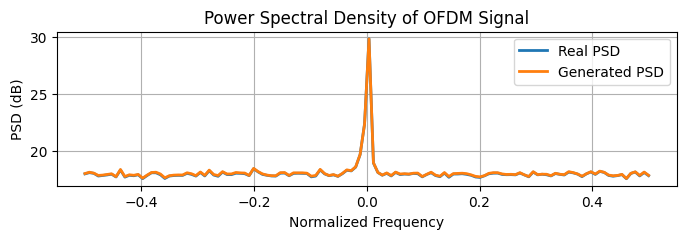

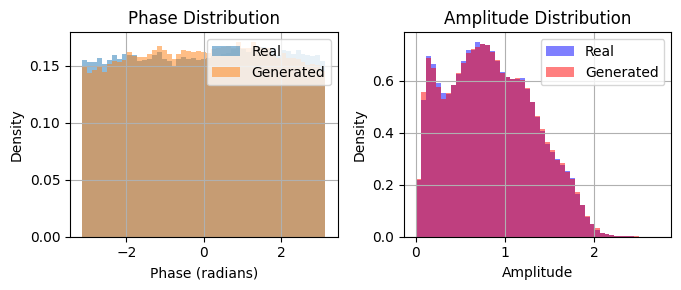

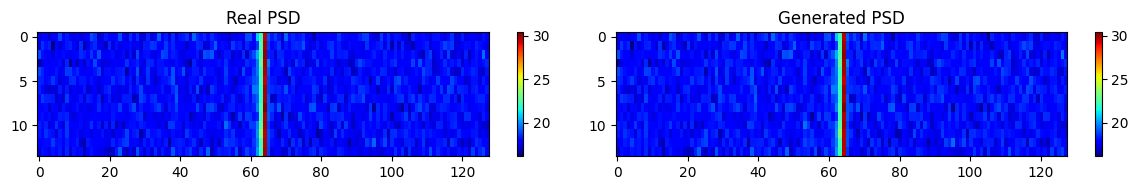

Iteration 5000/50000, Eb/No: 19.9708, Loss_tx: -0.7735, Loss_rx: -0.7895
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.7846e-03 | 3.0649e-02 |       38789 |     8107008 |           51 |        1664 |         5.8 |reached target block errors
Epoch [600/5000] w_d:-445457.8750 gp: 10519.4131, grad_norm: 22.7592 Loss_D: -434938.4688 Loss_G: -1084316.0000, mse(PSD): 0.0084
Iteration 6000/50000, Eb/No: 4.7822, Loss_tx: -0.4601, Loss_rx: -0.4652
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 3.7941e-03 | 2.4414e-02 |       37857 |     9977856 |           50 

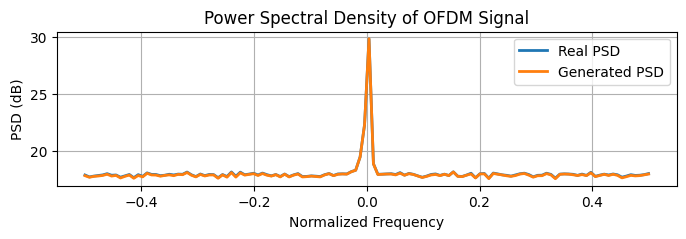

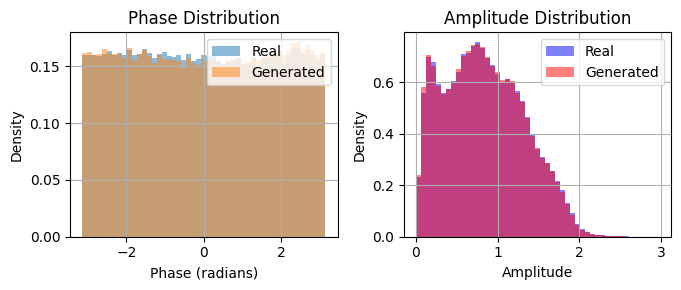

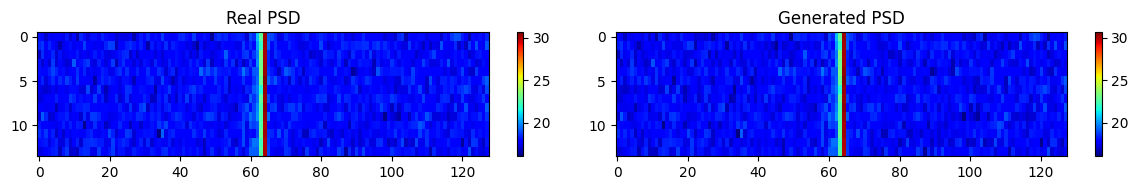

Epoch [800/5000] w_d:-554706.8750 gp: 5360.4102, grad_norm: 21.5743 Loss_D: -549346.4375 Loss_G: -1139181.5000, mse(PSD): 0.0036
Iteration 8000/50000, Eb/No: 0.4614, Loss_tx: -0.2576, Loss_rx: -0.2636
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.7964e-03 | 3.6222e-02 |       39762 |     6859776 |           51 |        1408 |         4.5 |reached target block errors
Epoch [900/5000] w_d:-580298.5000 gp: 5467.1821, grad_norm: 24.2705 Loss_D: -574831.3125 Loss_G: -1191732.0000, mse(PSD): 0.0022
Iteration 9000/50000, Eb/No: 10.6854, Loss_tx: -0.6934, Loss_rx: -0.7014
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------

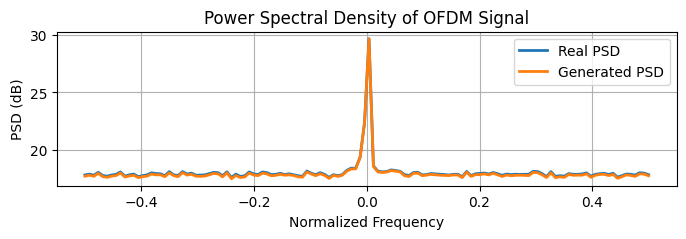

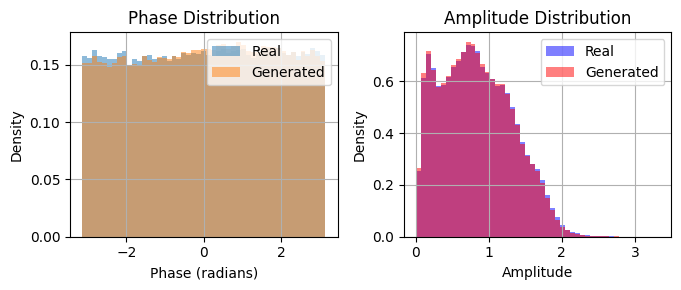

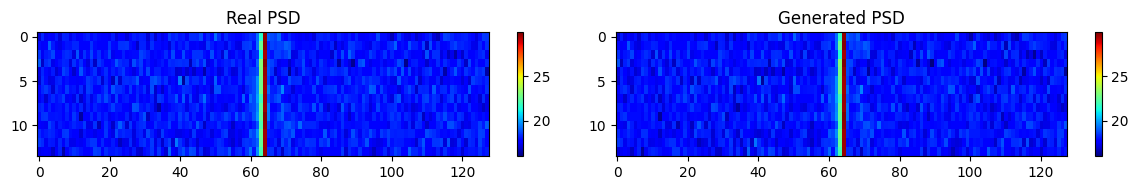

Iteration 10000/50000, Eb/No: 14.5136, Loss_tx: -0.7800, Loss_rx: -0.7841
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.6615e-03 | 1.1489e-02 |       35229 |    21202944 |           50 |        4352 |        14.3 |reached target block errors
Epoch [1100/5000] w_d:-668109.1250 gp: 6415.8604, grad_norm: 25.9622 Loss_D: -661693.2500 Loss_G: -1268229.0000, mse(PSD): 0.0104
Iteration 11000/50000, Eb/No: 17.7140, Loss_tx: -0.8370, Loss_rx: -0.8396
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.9644e-03 | 1.3281e-02 |       36751 |    18708480 |           

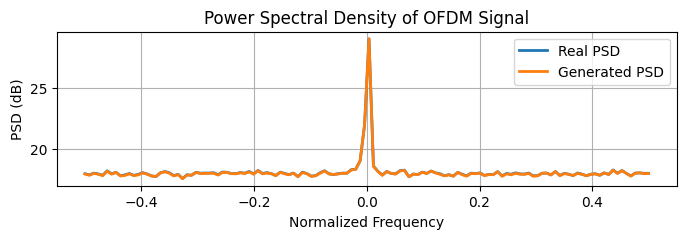

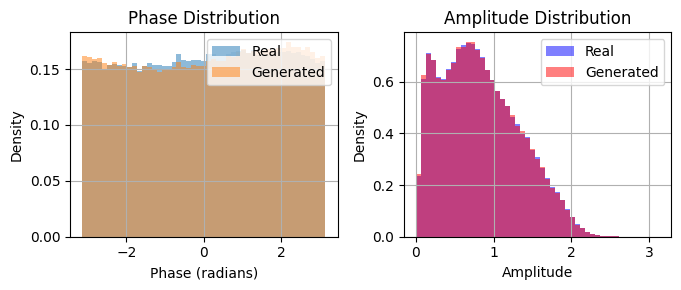

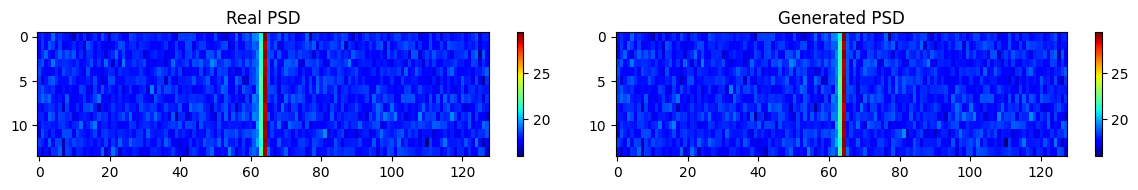

Epoch [1300/5000] w_d:-553939.3750 gp: 5472.9375, grad_norm: 23.9023 Loss_D: -548466.4375 Loss_G: -1553539.1250, mse(PSD): 0.0055
Iteration 13000/50000, Eb/No: 9.9472, Loss_tx: -0.6735, Loss_rx: -0.6800
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 2.5262e-03 | 1.5625e-02 |       39385 |    15590400 |           50 |        3200 |        10.3 |reached target block errors
Epoch [1400/5000] w_d:-727547.2500 gp: 12468.2803, grad_norm: 25.1445 Loss_D: -715079.0000 Loss_G: -1464143.3750, mse(PSD): 0.0086
Iteration 14000/50000, Eb/No: 8.2231, Loss_tx: -0.6119, Loss_rx: -0.6111
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
-----------------------------------------------------------------------------------

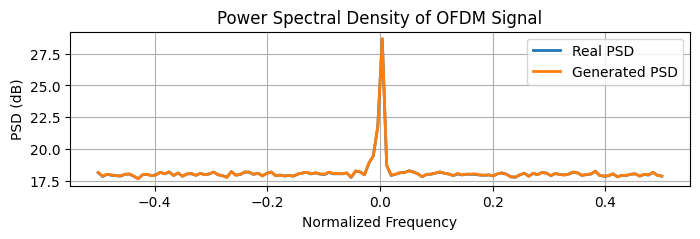

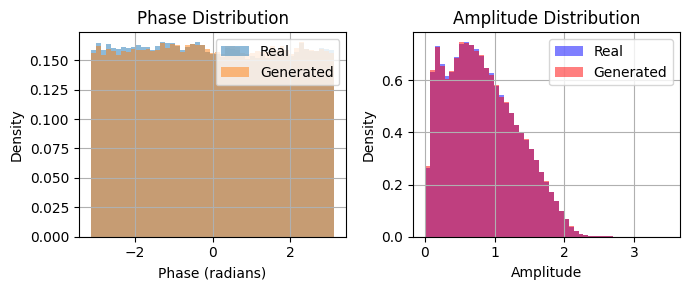

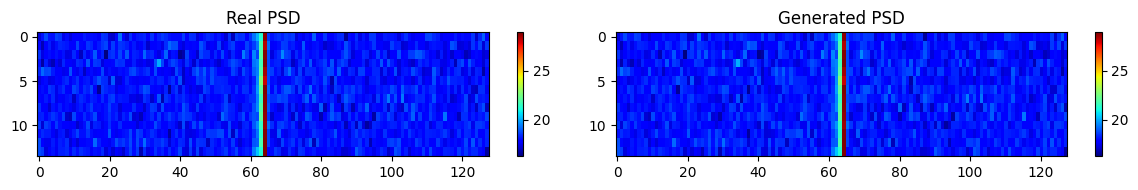

Iteration 15000/50000, Eb/No: 4.1974, Loss_tx: -0.4408, Loss_rx: -0.4414
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.9888e-03 | 1.5336e-02 |       33487 |    16837632 |           53 |        3456 |        11.1 |reached target block errors
Epoch [1600/5000] w_d:-662592.6250 gp: 9203.6816, grad_norm: 30.8540 Loss_D: -653388.9375 Loss_G: -1710939.7500, mse(PSD): 0.0029
Iteration 16000/50000, Eb/No: 8.3658, Loss_tx: -0.6110, Loss_rx: -0.6204
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 2.0952e-03 | 1.4468e-02 |       35278 |    16837632 |           50

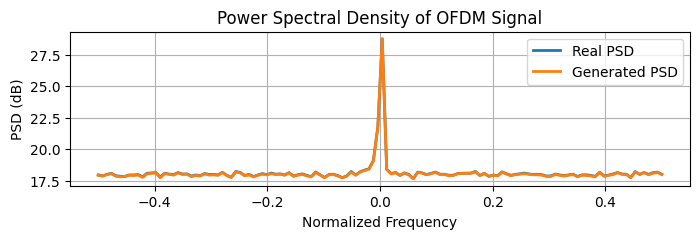

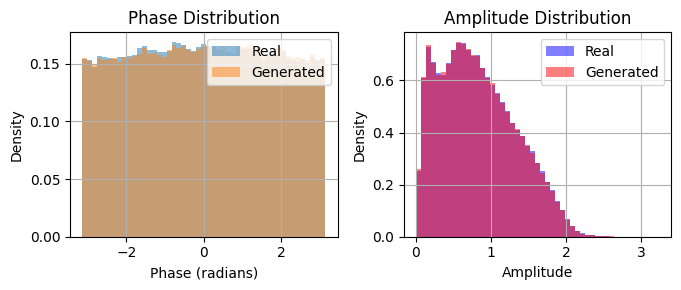

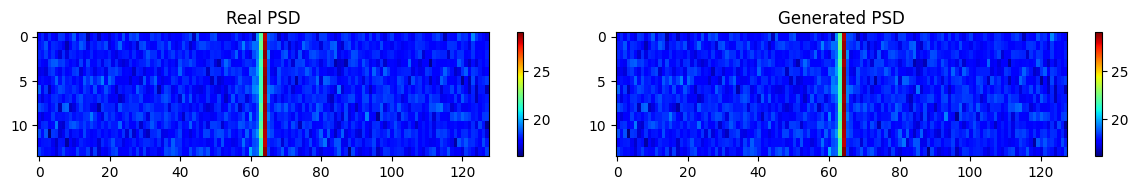

Epoch [1800/5000] w_d:-820976.1250 gp: 6718.0327, grad_norm: 26.1547 Loss_D: -814258.0625 Loss_G: -1736149.7500, mse(PSD): 0.0031
Iteration 18000/50000, Eb/No: 5.1505, Loss_tx: -0.4826, Loss_rx: -0.4852
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.8805e-03 | 1.2853e-02 |       36354 |    19332096 |           51 |        3968 |        12.7 |reached target block errors
Epoch [1900/5000] w_d:-917946.5000 gp: 12399.6543, grad_norm: 28.1041 Loss_D: -905546.8750 Loss_G: -1723550.5000, mse(PSD): 0.0047
Iteration 19000/50000, Eb/No: 3.1168, Loss_tx: -0.3962, Loss_rx: -0.3978
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
-----------------------------------------------------------------------------------

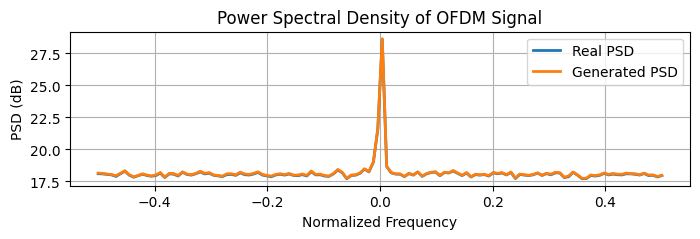

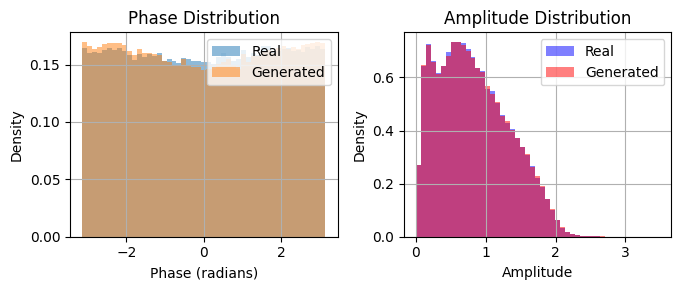

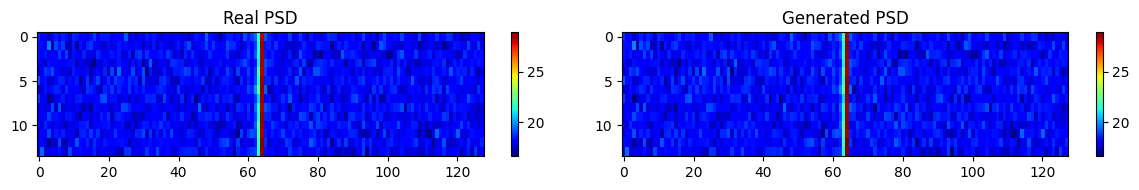

Iteration 20000/50000, Eb/No: 6.4630, Loss_tx: -0.5373, Loss_rx: -0.5468
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.6812e-03 | 1.3021e-02 |       31453 |    18708480 |           50 |        3840 |        13.3 |reached target block errors
Epoch [2100/5000] w_d:-807621.1250 gp: 8227.9307, grad_norm: 27.1490 Loss_D: -799393.1875 Loss_G: -1998386.6250, mse(PSD): 0.0057
Iteration 21000/50000, Eb/No: 16.2803, Loss_tx: -0.8749, Loss_rx: -0.8841
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.7056e-03 | 1.4278e-02 |       30845 |    18084864 |           5

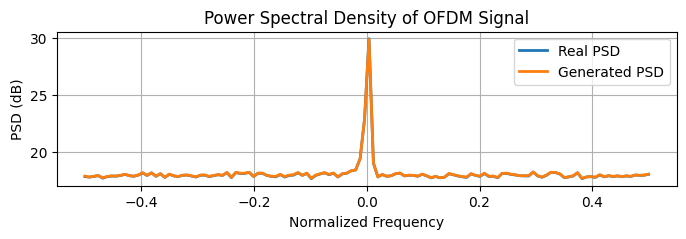

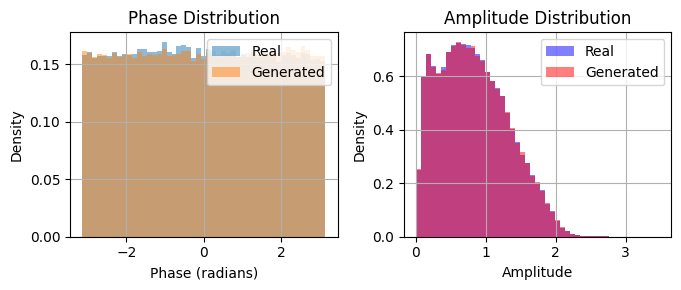

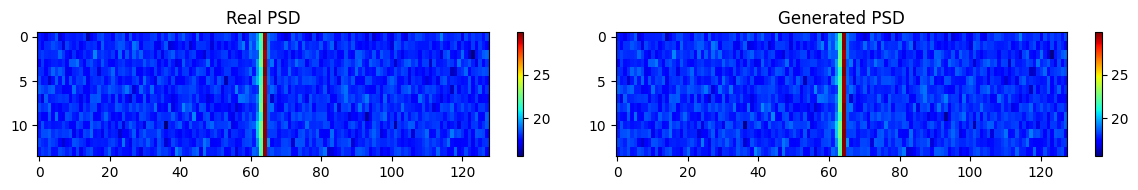

Epoch [2300/5000] w_d:-901558.5000 gp: 10346.3555, grad_norm: 27.1506 Loss_D: -891212.1250 Loss_G: -2125170.0000, mse(PSD): 0.0022
Iteration 23000/50000, Eb/No: 16.2698, Loss_tx: -0.8889, Loss_rx: -0.8902
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.2754e-03 | 8.3112e-03 |       37382 |    29309952 |           50 |        6016 |        19.3 |reached target block errors
Epoch [2400/5000] w_d:-898238.7500 gp: 11032.9346, grad_norm: 32.1810 Loss_D: -887205.8125 Loss_G: -2219453.5000, mse(PSD): 0.0040
Iteration 24000/50000, Eb/No: 14.3892, Loss_tx: -0.8529, Loss_rx: -0.8668
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
--------------------------------------------------------------------------------

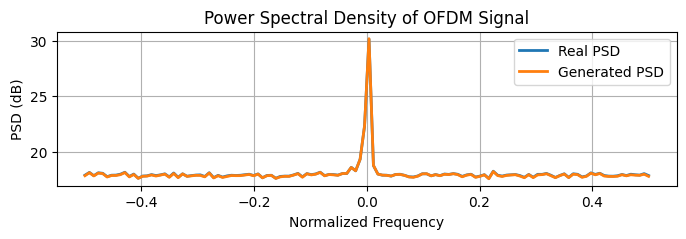

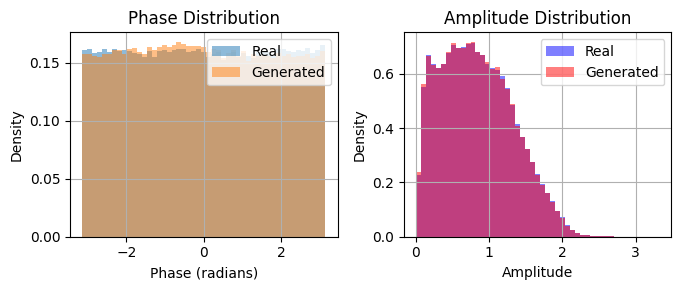

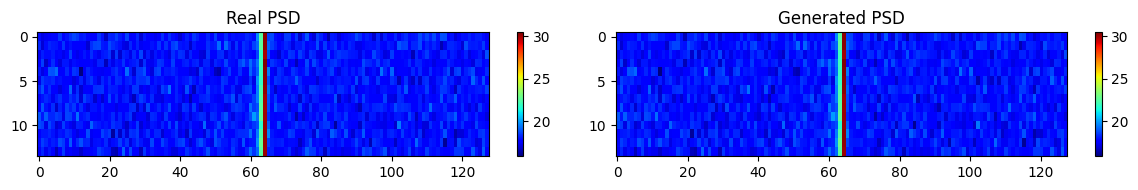

Iteration 25000/50000, Eb/No: 2.3931, Loss_tx: -0.3626, Loss_rx: -0.3648
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 9.9908e-04 | 7.9688e-03 |       31152 |    31180800 |           51 |        6400 |        20.5 |reached target block errors
Epoch [2600/5000] w_d:-978620.5000 gp: 18459.2090, grad_norm: 43.8755 Loss_D: -960161.3125 Loss_G: -2313477.0000, mse(PSD): 0.0023
Iteration 26000/50000, Eb/No: 2.9173, Loss_tx: -0.3853, Loss_rx: -0.3863
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.2665e-03 | 9.4477e-03 |       33963 |    26815488 |           5

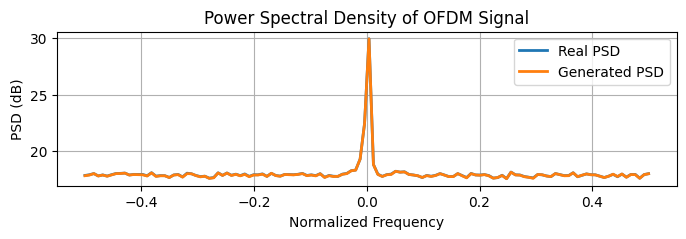

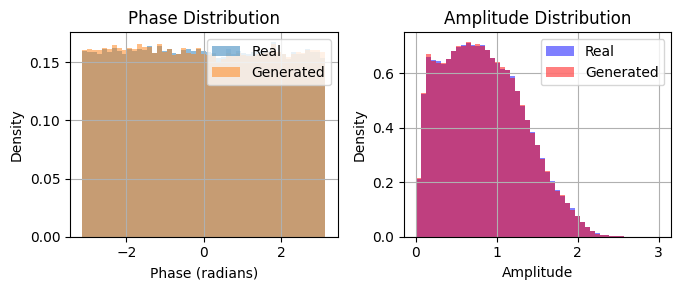

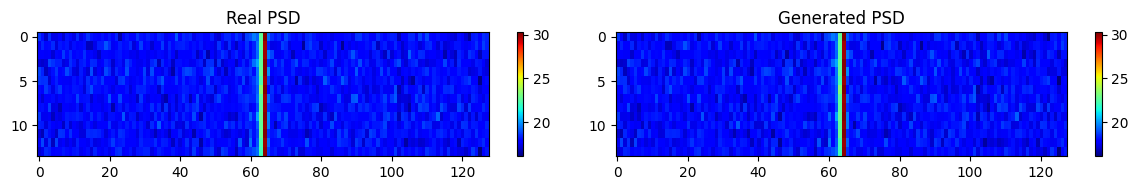

Epoch [2800/5000] w_d:-1012785.2500 gp: 10505.4873, grad_norm: 31.9787 Loss_D: -1002279.7500 Loss_G: -2467590.0000, mse(PSD): 0.0061
Iteration 28000/50000, Eb/No: 4.6012, Loss_tx: -0.4330, Loss_rx: -0.4423
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.5261e-03 | 3.1250e-02 |       36693 |     8107008 |           52 |        1664 |         5.8 |reached target block errors
Epoch [2900/5000] w_d:-866889.0000 gp: 8701.1865, grad_norm: 30.1817 Loss_D: -858187.8125 Loss_G: -2761826.7500, mse(PSD): 0.0014
Iteration 29000/50000, Eb/No: 12.8047, Loss_tx: -0.8090, Loss_rx: -0.8145
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
--------------------------------------------------------------------------------

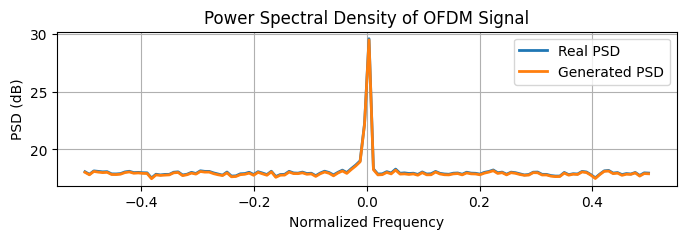

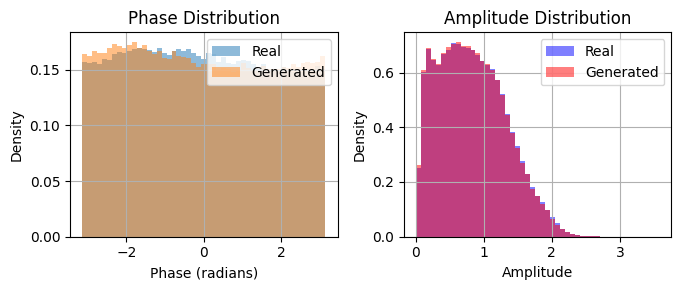

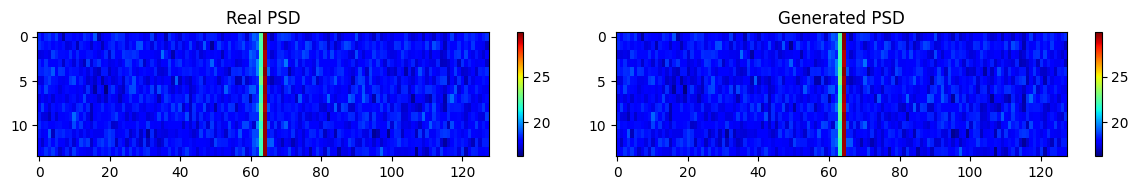

Iteration 30000/50000, Eb/No: 15.0206, Loss_tx: -0.8646, Loss_rx: -0.8754
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.6005e-03 | 1.0016e-02 |       38926 |    24321024 |           50 |        4992 |        16.0 |reached target block errors
Epoch [3100/5000] w_d:-1080785.7500 gp: 34778.2578, grad_norm: 59.7894 Loss_D: -1046007.5000 Loss_G: -2687315.0000, mse(PSD): 0.0016
Iteration 31000/50000, Eb/No: 4.6293, Loss_tx: -0.4586, Loss_rx: -0.4634
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.7629e-03 | 1.2601e-02 |       34080 |    19332096 |         

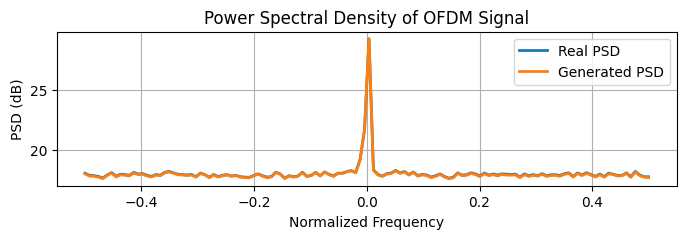

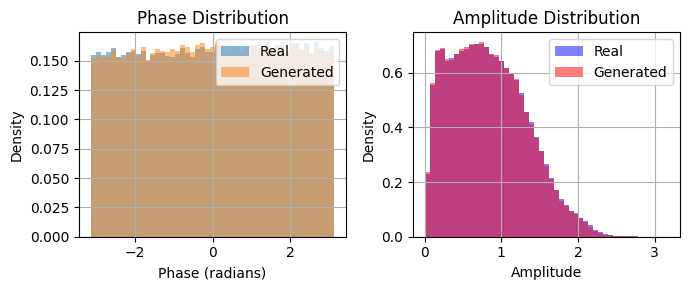

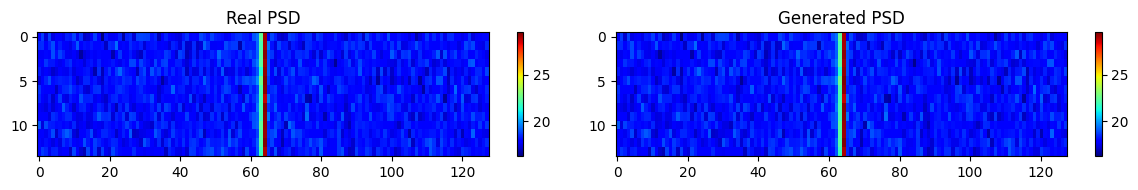

Epoch [3300/5000] w_d:-1171945.7500 gp: 15978.1816, grad_norm: 40.7272 Loss_D: -1155967.6250 Loss_G: -2777171.7500, mse(PSD): 0.0148
Iteration 33000/50000, Eb/No: 4.2196, Loss_tx: -0.4497, Loss_rx: -0.4520
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.0667e-03 | 9.2660e-03 |       28603 |    26815488 |           51 |        5504 |        18.4 |reached target block errors
Epoch [3400/5000] w_d:-1151880.2500 gp: 9642.8359, grad_norm: 29.9076 Loss_D: -1142237.3750 Loss_G: -2898769.0000, mse(PSD): 0.0019
Iteration 34000/50000, Eb/No: 2.3240, Loss_tx: -0.3609, Loss_rx: -0.3623
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
-------------------------------------------------------------------------------

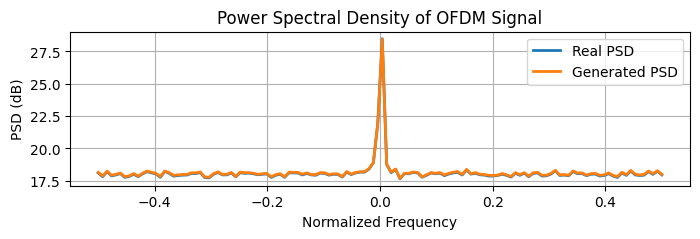

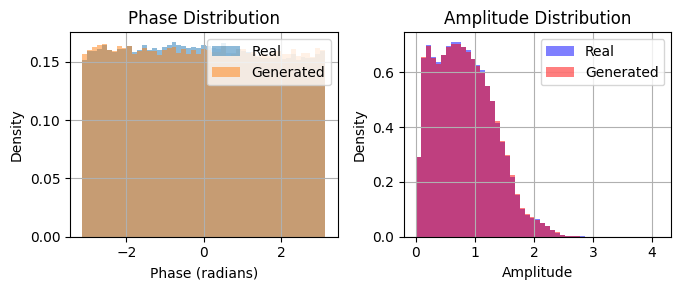

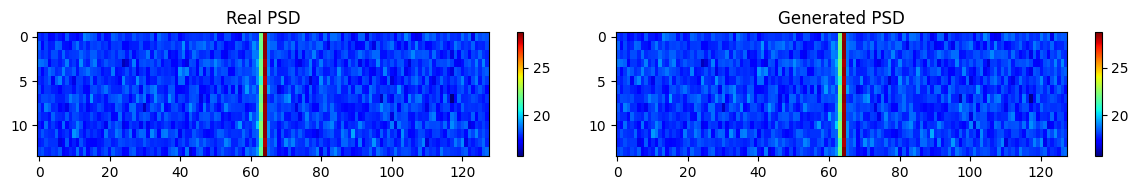

Iteration 35000/50000, Eb/No: 2.9543, Loss_tx: -0.3916, Loss_rx: -0.3909
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.8299e-03 | 1.3021e-02 |       34235 |    18708480 |           50 |        3840 |        13.4 |reached target block errors
Epoch [3600/5000] w_d:-1112652.0000 gp: 13083.8135, grad_norm: 36.4585 Loss_D: -1099568.1250 Loss_G: -3087009.2500, mse(PSD): 0.0106
Iteration 36000/50000, Eb/No: 10.9685, Loss_tx: -0.7662, Loss_rx: -0.7645
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.2607e-03 | 9.2660e-03 |       33805 |    26815488 |         

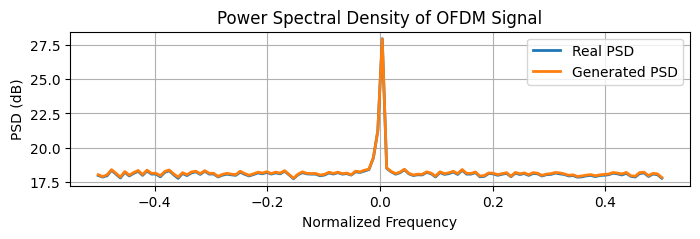

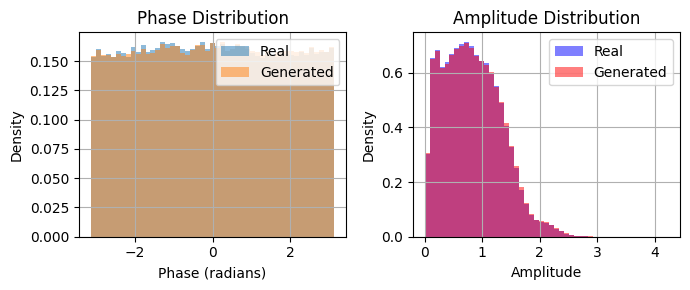

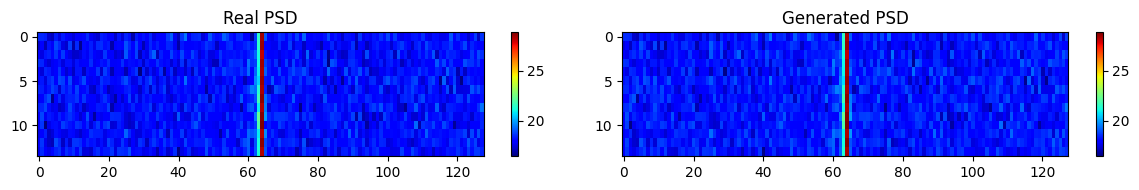

Epoch [3800/5000] w_d:-1349879.5000 gp: 10452.2520, grad_norm: 29.6812 Loss_D: -1339427.2500 Loss_G: -3075070.5000, mse(PSD): 0.0016
Iteration 38000/50000, Eb/No: 0.0078, Loss_tx: -0.2670, Loss_rx: -0.2659
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.3061e-03 | 9.7656e-03 |       32579 |    24944640 |           50 |        5120 |        16.5 |reached target block errors
Epoch [3900/5000] w_d:-1163225.0000 gp: 16433.5801, grad_norm: 41.4754 Loss_D: -1146791.3750 Loss_G: -3340635.0000, mse(PSD): 0.0044
Iteration 39000/50000, Eb/No: 13.3773, Loss_tx: -0.8526, Loss_rx: -0.8530
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
-----------------------------------------------------------------------------

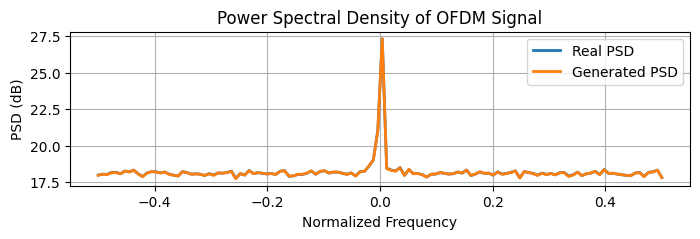

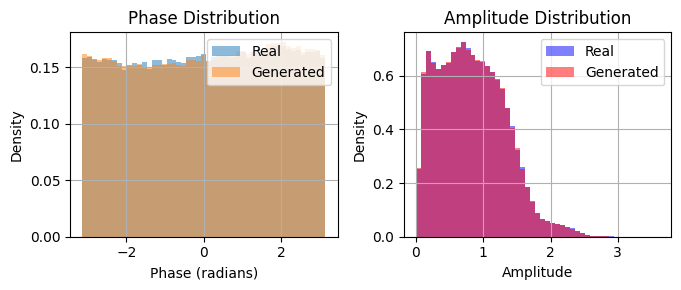

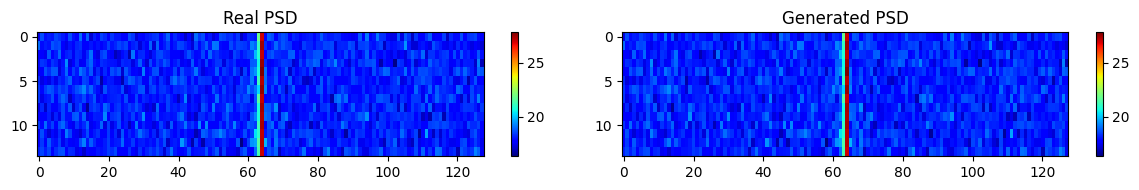

Iteration 40000/50000, Eb/No: 11.9449, Loss_tx: -0.8015, Loss_rx: -0.8051
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.1222e-03 | 8.6806e-03 |       31491 |    28062720 |           50 |        5760 |        18.4 |reached target block errors
Epoch [4100/5000] w_d:-1274375.2500 gp: 12811.9023, grad_norm: 36.6772 Loss_D: -1261563.3750 Loss_G: -3419437.7500, mse(PSD): 0.0009
Iteration 41000/50000, Eb/No: 3.1887, Loss_tx: -0.4050, Loss_rx: -0.4065
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.1674e-03 | 8.4918e-03 |       33487 |    28686336 |         

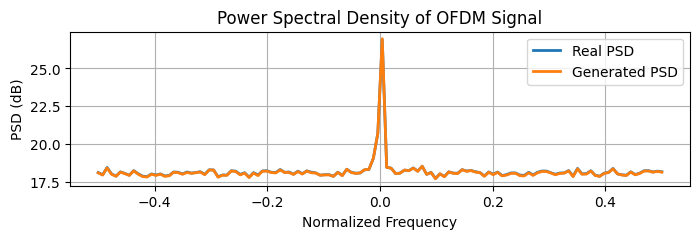

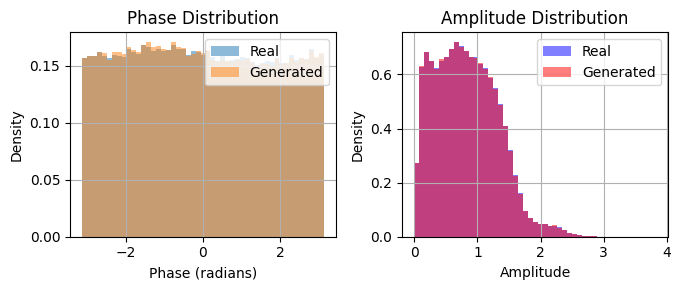

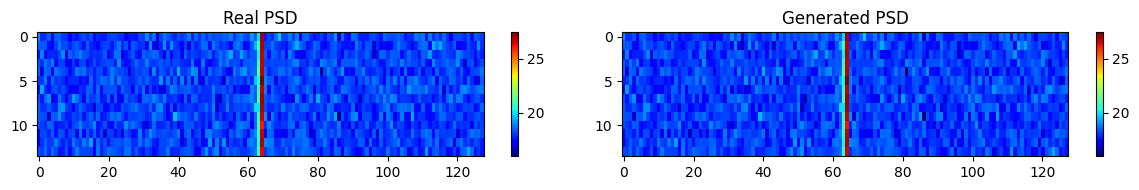

Epoch [4300/5000] w_d:-1358495.0000 gp: 12833.1592, grad_norm: 36.0420 Loss_D: -1345661.8750 Loss_G: -3532848.5000, mse(PSD): 0.0016
Iteration 43000/50000, Eb/No: 14.6778, Loss_tx: -0.8907, Loss_rx: -0.8989
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.1140e-03 | 9.3006e-03 |       29178 |    26191872 |           50 |        5376 |        18.7 |reached target block errors
Epoch [4400/5000] w_d:-1371715.2500 gp: 11578.6084, grad_norm: 34.8672 Loss_D: -1360136.6250 Loss_G: -3642425.2500, mse(PSD): 0.0011
Iteration 44000/50000, Eb/No: 8.4528, Loss_tx: -0.6559, Loss_rx: -0.6679
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
-----------------------------------------------------------------------------

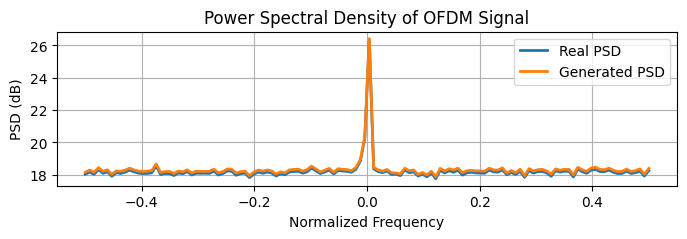

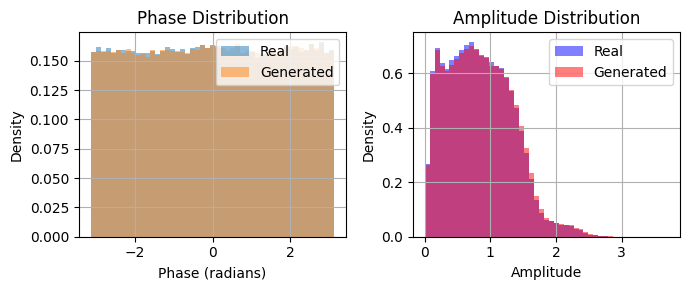

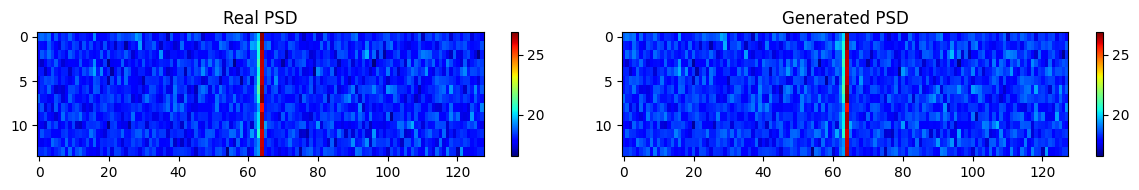

Iteration 45000/50000, Eb/No: 13.0380, Loss_tx: -0.8510, Loss_rx: -0.8515
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.4275e-03 | 9.7180e-03 |       36498 |    25568256 |           51 |        5248 |        16.8 |reached target block errors
Epoch [4600/5000] w_d:-1467875.2500 gp: 14961.4238, grad_norm: 35.5388 Loss_D: -1452913.8750 Loss_G: -3733875.2500, mse(PSD): 0.0025
Iteration 46000/50000, Eb/No: 18.6846, Loss_tx: -0.9656, Loss_rx: -0.9742
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.3550e-03 | 8.8778e-03 |       37180 |    27439104 |        

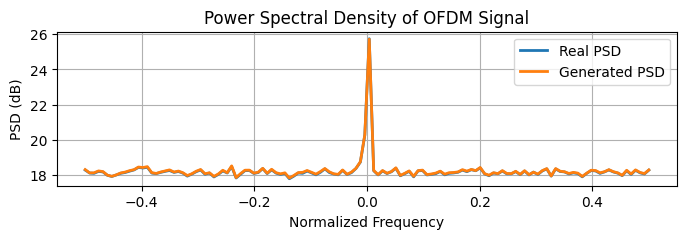

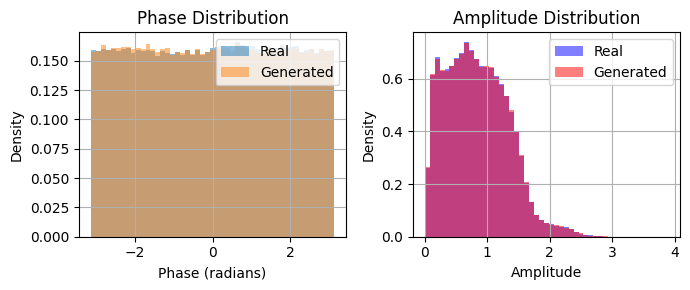

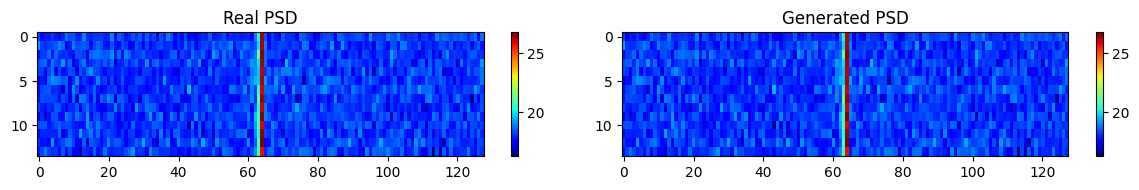

Epoch [4800/5000] w_d:-1544453.5000 gp: 13211.0928, grad_norm: 33.6851 Loss_D: -1531242.3750 Loss_G: -3855067.0000, mse(PSD): 0.0032
Iteration 48000/50000, Eb/No: 12.5273, Loss_tx: -0.8347, Loss_rx: -0.8374
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.0913e-03 | 7.9657e-03 |       34708 |    31804416 |           52 |        6528 |        21.0 |reached target block errors
Epoch [4900/5000] w_d:-1373717.0000 gp: 13806.2969, grad_norm: 34.3963 Loss_D: -1359910.7500 Loss_G: -4137528.7500, mse(PSD): 0.0059
Iteration 49000/50000, Eb/No: 10.1850, Loss_tx: -0.7404, Loss_rx: -0.7386
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
----------------------------------------------------------------------------

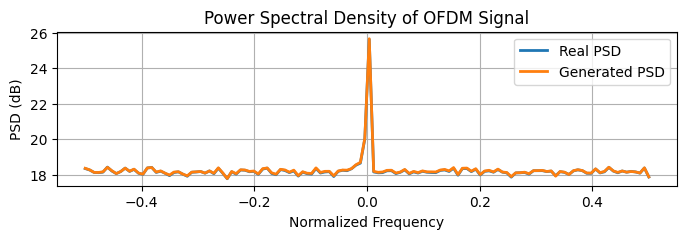

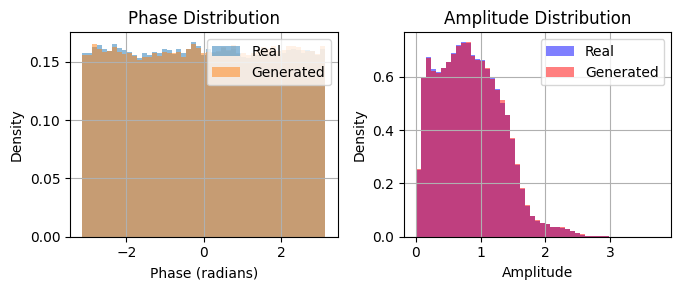

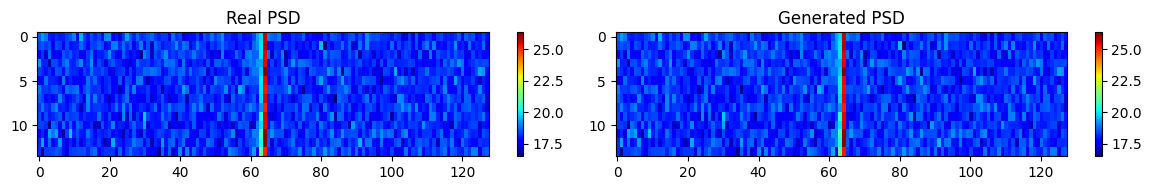

Iteration 50000/50000, Eb/No: 5.9522, Loss_tx: -0.5387, Loss_rx: -0.5480
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.1335e-03 | 8.8315e-03 |       32515 |    28686336 |           52 |        5888 |        20.4 |reached target block errors


In [32]:
offset = 0
for i in tqdm(range(offset, num_training_iterations+1)):  
    
    train_GAN = True if (i % 10 == 0) else False # Train GAN every 10 iterations (50000/10=5000 times)
    if train_GAN:
        # Sampling a batch of SNRs
        ebno_db = tf.constant(10.0, tf.float32)
        
        _, x_rg, _, y_real, h_freq, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)

        # h_real = h_freq[:,:,:,0,0,:,:] # (128, 1, 1, 14, 128)
    
        # condition
        condition = y_real # y_real, h_freq, h_hat, pilots
        
        d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, condition) 
        
        gan_weights_G = WG.get_weights()
        gan_weights_D = WD.get_weights()
    
        # -----------------------------------------------------------------------
        list_D.append(loss_D)
        list_G.append(loss_G)  
        
        if i % 1000 == 0: 
            psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
            psd_generated = compute_psd(y_fake)
            mse_psd = tf.reduce_mean((psd_real - psd_generated)**2)
    
            print(f"Epoch [{i//10}/{num_training_iterations//10}] w_d:{loss_D.numpy()-gp.numpy():.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, mse(PSD): {mse_psd.numpy():.4f}") 
    
        if i % 2500 == 0: 
            print(np.mean(y_fake), np.mean(y_real))
            
            psd_real_line = compute_psd_line(y_real)
            psd_generated_line = compute_psd_line(y_fake)
            plot_psd_line(psd_real_line, psd_generated_line)
            
            plot_phase_amp_distribution(y_real, y_fake)
    
            plot_psd(psd_real, psd_generated)
    
        if i % 5000 == 0: 
            # save GAN weights
            with open(f'gan_weights/receivedY_gan_weights_G_{i}.pkl', 'wb') as f2:
                pickle.dump(gan_weights_G, f2)
            with open(f'gan_weights/receivedY_gan_weights_D_{i}.pkl', 'wb') as f3:
                    pickle.dump(gan_weights_D, f3)

            np.savez('gan_losses_receivedY.npz', generator=np.asarray(list_G), discriminator=np.asarray(list_D))

    # -----------------------------------------------------------------------
    gan_weights_G = WG.get_weights()
    model._gan_channel.set_weights(gan_weights_G)
    # -----------------------------------------------------------------------
    
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    loss_tx, y_gen, y_real = E2E_train__tx_step(ebno_db)
    loss_rx = E2E_train__rx_step(ebno_db)
     
    for layer in model.layers:
        layer.trainable = True
    weights = model.get_weights()
        
    if i % 1000 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss_tx: {loss_tx.numpy():.4f}, Loss_rx: {loss_rx.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
        eval_model.set_weights(weights)
        # validation at 3.5dB
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 5000 == 0:
        with open(f'weights_trained/receivedY_model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open(model_weights_path_trained, 'wb') as f:
    pickle.dump(weights, f)

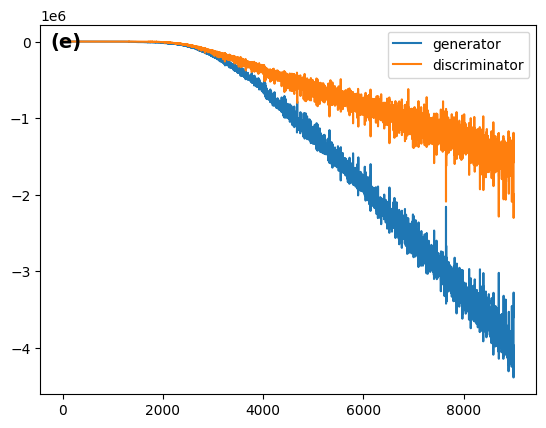

In [33]:
G_L = np.asarray(list_G)
D_L = np.asarray(list_D)
plt.figure()
plt.plot(G_L, label='generator')
plt.plot(D_L, label='discriminator')
plt.legend()
plt.savefig('gan_loss_plot_receivedY.png', dpi=300)  # Save the plot as an image
plt.text(0.02, 0.98, '(e)', transform=plt.gca().transAxes, 
         fontsize=14, fontweight='bold', va='top', ha='left')
plt.show()

np.savez('gan_losses_receivedY.npz', generator=G_L, discriminator=D_L)

In [ ]:
# Load the saved losses
data = np.load('gan_losses_receivedY.npz')
# G_L = data['generator'][:5000]  # Limit to first 4000 data points
# D_L = data['discriminator'][:5000]  # Limit to first 4000 data points

iterations = np.arange(len(G_L)) * 100

plt.figure()
plt.plot(iterations, G_L, label='generator')
plt.plot(iterations, D_L, label='discriminator')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.text(0.02, 0.98, '(a)', transform=plt.gca().transAxes, 
         fontsize=14, fontweight='bold', va='top', ha='left')
plt.savefig('gan_loss_plot_receivedY.png', dpi=300)  # Save the plot as an image
plt.show()

## Joint Training (baseline)

In [46]:
offset = 0
grad_check = 0
for i in tqdm(range(offset, num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    weights = model.trainable_weights
    # for w in weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(training_batch_size, ebno_db, use_gan_channel=False)
        loss = -rate 
    
    grads = tape.gradient(loss, weights)
    optimizer.apply_gradients(zip(grads, weights))

    # Check which gradients are None
    if grad_check == 0:
        print("=" * 20)
        for i, (grad, weight) in enumerate(zip(grads, weights)):
            if grad is None:
                print(f"❌ None    : {weight.name} - Shape: {weight.shape}")
            else:
                print(f"✅ Valid   : {weight.name} - Shape: {weight.shape}")
        print("=" * 20)
        grad_check += 1
     
    if i % 2500 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
        eval_model.set_weights(weights)
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 5000 == 0:
        with open(f'weights_trained/baseline_model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open('baseline_weights_NNmapper', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/50001 [00:00<?, ?it/s]

✅ Valid   : mapper_5/constellation_5/Variable:0 - Shape: (2, 64)
❌ None    : conv2d_85/kernel:0 - Shape: (3, 3, 104, 128)
❌ None    : conv2d_86/kernel:0 - Shape: (3, 3, 128, 256)
❌ None    : conv2d_87/kernel:0 - Shape: (3, 3, 256, 512)
❌ None    : conv2d_88/kernel:0 - Shape: (3, 3, 512, 2)
✅ Valid   : neural_receiver_input_conv/kernel:0 - Shape: (3, 3, 3, 128)
✅ Valid   : neural_receiver_input_conv/bias:0 - Shape: (128,)
✅ Valid   : neural_receiver_output_conv/kernel:0 - Shape: (3, 3, 128, 6)
✅ Valid   : neural_receiver_output_conv/bias:0 - Shape: (6,)
✅ Valid   : neural_receiver_residual_block_1/layer_normalization_48/gamma:0 - Shape: (128, 128, 14)
✅ Valid   : neural_receiver_residual_block_1/layer_normalization_48/beta:0 - Shape: (128, 128, 14)
✅ Valid   : neural_receiver_residual_block_1/conv2d_89/kernel:0 - Shape: (3, 3, 128, 128)
✅ Valid   : neural_receiver_residual_block_1/conv2d_89/bias:0 - Shape: (128,)
✅ Valid   : neural_receiver_residual_block_1/layer_normalization_49/gamma:

## Learned Constellation <a class="anchor" id="Constellation"></a>

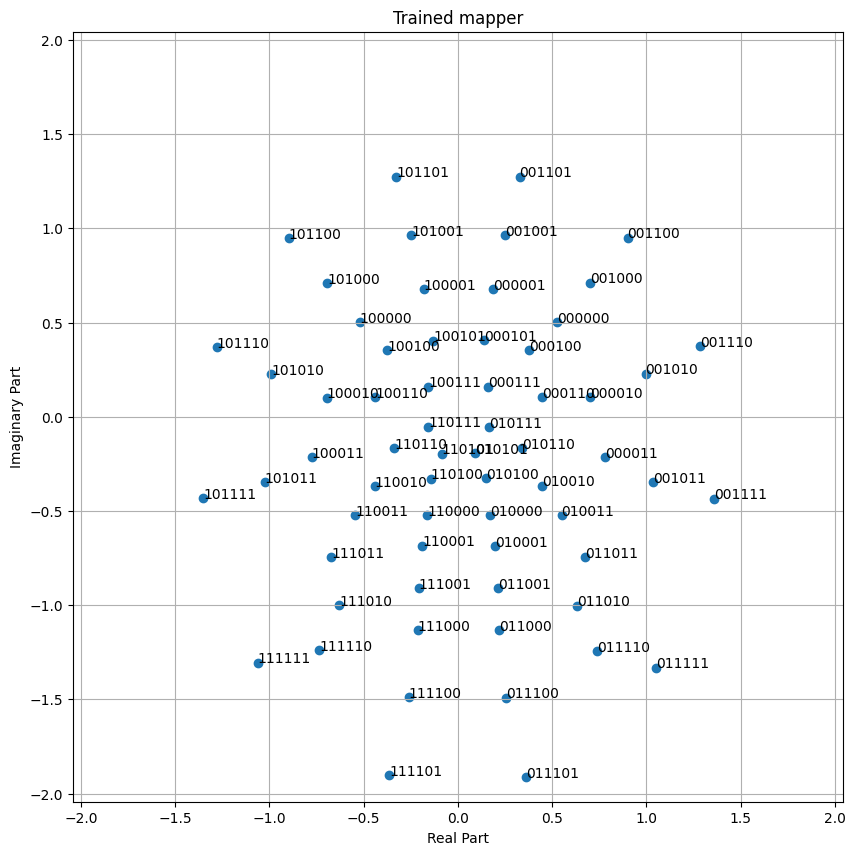

In [52]:
# Utility function to load and set weights of a mode
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32))
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
model = E2ESystem(training=True)
load_weights(model, "weights_trained/baseline_model_weights_50000.pkl")

# fig = model.constellation.show()
constellation = model.constellation
figsize=(10,10)
maxval = np.max(np.abs(constellation.points))*1.05
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation.points), np.imag(constellation.points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained mapper")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
for j, p in enumerate(constellation.points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )

In [ ]:
# current_config = {
#     'weight_path': 'weights_trained/pilots_model_weights_50000.pkl',
#     'condition_label': r'$\mathbf{x}_p$ and $\mathbf{y}_p$', 
#     'subplot_index': 0,  # 0, 1, or 2
#     'subplot_label': '(a)'  # '(a)', '(b)', or '(c)'
# }

# current_config = {
#     'weight_path': 'weights_trained/hhat_model_weights_50000.pkl',
#     'condition_label': r'$\hat{\mathbf{h}}$', 
#     'subplot_index': 1,
#     'subplot_label': '(b)'
# }

current_config = {
    'weight_path': 'weights_trained/receivedY_model_weights_50000.pkl',
    'condition_label': r'$\mathbf{Y}_{rg}$', 
    'subplot_index': 2,
    'subplot_label': '(c)'
}

# File to store the figure state
data_state_file = 'constellation_data_state.pkl'

def extract_constellation_data(weight_path):
    """Extract constellation data without plotting"""
    model = E2ESystem(training=True)
    load_weights(model, weight_path)
    constellation = model.constellation
    return constellation.points

# Load existing data or create new storage
if os.path.exists(data_state_file):
    with open(data_state_file, 'rb') as f:
        plot_data = pickle.load(f)
    print(f"Loaded existing data. Completed: {list(plot_data.keys())}")
else:
    plot_data = {}
    print("Created new data storage")

# Extract and store constellation data for current config
subplot_idx = current_config['subplot_index']
if subplot_idx not in plot_data:
    print(f"Extracting data for subplot {subplot_idx}: {current_config['condition_label']}")
    
    constellation_points = extract_constellation_data(current_config['weight_path'])
    
    plot_data[subplot_idx] = {
        'points': constellation_points,
        'condition_label': current_config['condition_label'],
        'subplot_label': current_config['subplot_label']
    }
    
    # Save the data
    with open(data_state_file, 'wb') as f:
        pickle.dump(plot_data, f)
        
    print(f"Saved data for subplot {subplot_idx}")
else:
    print(f"Data for subplot {subplot_idx} already exists")

print(f"Progress: {len(plot_data)}/3 subplots completed")

# Create and save the complete figure when all data is ready
if len(plot_data) == 3:
    print("All data ready! Creating final plot...")
    
    # Set IEEE paper style
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'font.family': 'serif',
        'font.serif': 'Times New Roman'
    })
    
    # Create fresh figure
    fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
    
    # Plot all subplots
    for i in range(3):
        data = plot_data[i]
        points = data['points']
        condition_label = data['condition_label']
        subplot_label = data['subplot_label']
        
        maxval = np.max(np.abs(points)) * 1.05
        axes[i].set_xlim(-maxval, maxval)
        axes[i].set_ylim(-maxval, maxval)
        axes[i].scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        axes[i].set_aspect("equal", adjustable="box")
        axes[i].grid(True, which="both", axis="both", alpha=0.3)
        axes[i].set_title(f"{subplot_label} {condition_label}")
        axes[i].set_xlabel("Real Part")
        axes[i].set_ylabel("Imaginary Part")
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.4)
    
    # Save EPS
    plt.savefig('learned_constellations.eps', format='eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved learned_constellations.eps successfully!")
    
    # Clean up
    if os.path.exists(data_state_file):
        os.remove(data_state_file)
        print("Cleaned up data file")

else:
    # Show preview of current data
    if plot_data:
        plt.figure(figsize=(3, 3))
        latest_data = plot_data[max(plot_data.keys())]
        points = latest_data['points']
        maxval = np.max(np.abs(points)) * 1.05
        plt.xlim(-maxval, maxval)
        plt.ylim(-maxval, maxval)
        plt.scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        plt.title(f"Preview: {latest_data['condition_label']}")
        plt.grid(True, alpha=0.3)
        plt.show()

## Evaluation of the Neural Receiver <a class="anchor" id="Evaluation-of-the-Neural-Receiver"></a>

In [35]:
eval_model = E2ESystem(training=False)
with open('weights_trained/receivedY_model_weights_50000.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-gan-trained'] = bler.numpy()
BER['neural-receiver-gan-trained'] = ber.numpy()

with open(results_filename, 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.8653e-01 | 1.0000e+00 |      178687 |      623616 |          128 |         128 |         0.5 |reached target block errors
      0.5 | 2.7606e-01 | 1.0000e+00 |      172157 |      623616 |          128 |         128 |         0.5 |reached target block errors
      1.0 | 2.6839e-01 | 1.0000e+00 |      167373 |      623616 |          128 |         128 |         0.5 |reached target block errors
      1.5 | 2.5397e-01 | 1.0000e+00 |      158379 |      623616 |          128 |         128 |         0.5 |reached target block errors
      2.0 | 2.4270e-01 | 1.0000e+00 |      151351 |      623616 |          128 |         128 |         0.5 |reached target block errors
      2.5 | 2.2954e-01 | 1.0000e+00 |      143147 |      623616 |

In [ ]:
eval_model = E2ESystem(training=False)
with open('weights_trained/baseline_model_weights_50000.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-trained'] = bler.numpy()
BER['neural-receiver-trained'] = ber.numpy()

with open('baseline_model_result.pkl', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.9038e-01 | 1.0000e+00 |      181086 |      623616 |          128 |         128 |         0.6 |reached target block errors
      0.5 | 2.8135e-01 | 1.0000e+00 |      175452 |      623616 |          128 |         128 |         0.4 |reached target block errors
      1.0 | 2.6946e-01 | 1.0000e+00 |      168037 |      623616 |          128 |         128 |         0.4 |reached target block errors
      1.5 | 2.5860e-01 | 1.0000e+00 |      161265 |      623616 |          128 |         128 |         0.4 |reached target block errors
      2.0 | 2.4628e-01 | 1.0000e+00 |      153583 |      623616 |          128 |         128 |         0.4 |reached target block errors
      2.5 | 2.3584e-01 | 1.0000e+00 |      147075 |      623616 |

Finally, we plots the BLERs

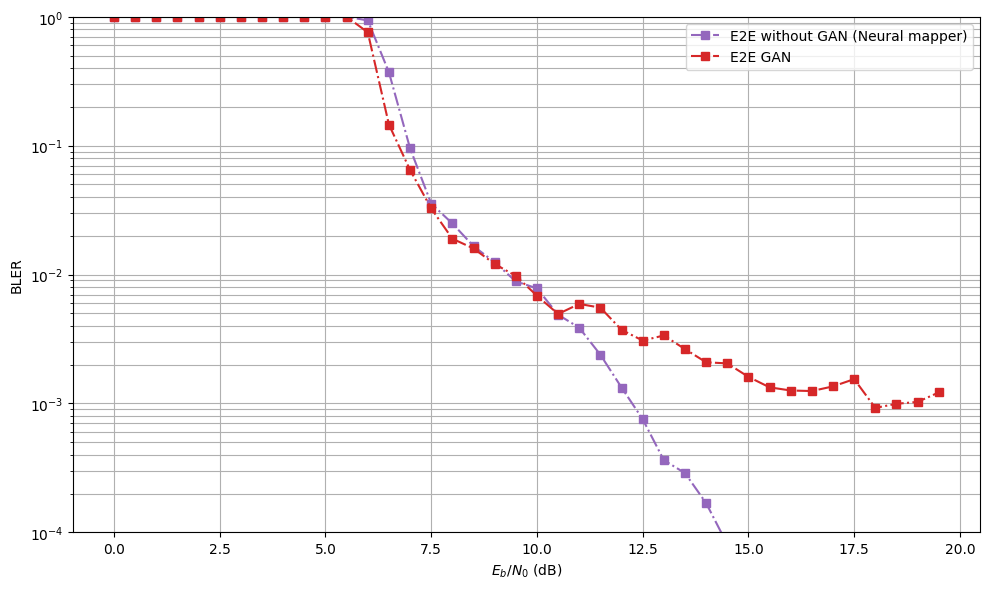

In [54]:
plt.figure(figsize=(10,6))

with open('baseline_model_result.pkl', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_st = BER
BLER_st = BLER
with open(results_filename, 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_g = BER
BLER_g = BLER

# plt.semilogy(ebno_dbs, BER_st['baseline-perfect-csi'], 'o-', c=f'C0', label=f'Baseline - Perfect CSI')
# plt.semilogy(ebno_dbs, BER_st['baseline-ls-estimation'], 'x--', c=f'C1', label=f'Baseline - LS Estimation')
# plt.semilogy(ebno_dbs, BLER_st['neural-receiver-standard'], 's-.', c=f'C2', label=f'E2E without GAN (QAM mapper)')
plt.semilogy(ebno_dbs, BLER_st['neural-receiver-trained'], 's-.', c=f'C4', label=f'E2E without GAN (Neural mapper)')
plt.semilogy(ebno_dbs, BLER_g['neural-receiver-gan-trained'], 's-.', c=f'C3', label=f'E2E GAN')

plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.legend()
plt.tight_layout()

In [ ]:
from scipy.stats import gaussian_kde

model = E2ESystem('neural-receiver-trained', use_gan_channel=True)
eval_model = E2ESystem('neural-receiver-trained')

model(1, tf.constant(10.0, tf.float32))
with open(model_weights_path_trained, 'rb') as f:
    weights = pickle.load(f)
model.set_weights(weights)

eval_model(1, tf.constant(10.0, tf.float32))
names = [w.name for w in model.trainable_weights]
eval_weights = [weight for name, weight in zip(names, weights) if "gan_channel" not in name]
eval_model.set_weights(eval_weights)

model.summary()
eval_model.summary()

nn_para = np.zeros(1)
for layer in model.layers:
    for weight in layer.weights:
        nn_para = np.concatenate((nn_para, weight.numpy().reshape(-1)), axis=0)

# Gaussian kernel density estimate
data = nn_para  # Replace with your data
kde = gaussian_kde(data[0:1000])

x = np.linspace(min(data), max(data), 1000)

plt.figure(figsize=(8, 6))
plt.plot(x, kde(x), label='PDF')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Probability Density Function')
plt.legend()
plt.grid(True)
plt.show()

## References <a class="anchor" id="References"></a>

[1] M. Honkala, D. Korpi and J. M. J. Huttunen, "DeepRx: Fully Convolutional Deep Learning Receiver," in IEEE Transactions on Wireless Communications, vol. 20, no. 6, pp. 3925-3940, June 2021, doi: 10.1109/TWC.2021.3054520.

[2] F. Ait Aoudia and J. Hoydis, "End-to-end Learning for OFDM: From Neural Receivers to Pilotless Communication," in IEEE Transactions on Wireless Communications, doi: 10.1109/TWC.2021.3101364.

[3] Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun, "Deep Residual Learning for Image Recognition", Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2016, pp. 770-778

[4] G. Böcherer, "Achievable Rates for Probabilistic Shaping", arXiv:1707.01134, 2017.